# Display features

In [ ]:
import pickle

with open(r"C:\Users\bilel.guetarni\Desktop\SEQ-RT\artix.pkl", "rb") as f:
    artix = pickle.load(f)

with open(r"C:\Users\bilel.guetarni\Desktop\SEQ-RT\hnscc.pkl", "rb") as f:
    hnscc = pickle.load(f)

In [ ]:
for p in hnscc:
    for ct in p.ct:
        if ct.rtdose is None:
            print(f"ct {ct.path} has no RTDOSE")

        if ct.rtstruct is None:
            print(f"ct {ct.path} has no RTSTRUCT")

In [ ]:
p.ct[0].rtdose.path

In [ ]:
import pandas
import re

def transform_(x):
    if isinstance(x, str):
        digits = re.findall("\d", x)
        if len(digits) == 0:
            return None
        else:
            return int(digits[0])
    else:
        return None

def retrieve_xero_info(p):
    cm = pandas.DataFrame(p.clinical_measurements)
    cm = cm[(cm["type"] == "AE") & (cm["sample"] == "XEROSTOMIE")]
    cm["value"] = cm["value"].apply(transform_)
    cm.loc[(cm["visitID"] == "S0"), "visitID"] = "Inclusion"
    if (cm[(cm["visitID"] == "Inclusion") & (cm["sample"] == "XEROSTOMIE")]["value"].astype('Int64') > 0).any():
        # exclude patient because xerstomia baseline present
        xerostomia = None
    else:
        try:
            cm = cm[cm["visitID"] == "M6"]
            xerostomia = int(cm["value"].values[0])
        except (IndexError, ValueError):
            xerostomia = None
    return xerostomia

xero = list(map(retrieve_xero_info, artix))
stats = {k: xero.count(k) for k in set(xero)}
print("artix:")
for j, c in stats.items():
    print(f"\t {j}: {c} ({int(100*c/len(xero))}%)")

In [ ]:
def retrieve_xero_info(p):
    try:
        xerostomia = int(p.clinical['Xerostomia Grade'])
    except ValueError:
        xerostomia = None
    return xerostomia

xero = list(map(retrieve_xero_info, hnscc))
stats = {k: xero.count(k) for k in set(xero)}
print("hnscc:")
for j, c in stats.items():
    print(f"\t {j}: {c} ({int(100*c/len(xero))}%)")

# Fit

### original
parotid_gland_ipsi
parotid_gland_contra
submandibular_gland_ipsi
submandibular_gland_contra
mandible
oral_cavity

### total segmentator
parotid_gland_left
parotid_gland_right
submandibular_gland_right
submandibular_gland_left
superior_pharyngeal_constrictor
middle_pharyngeal_constrictor
inferior_pharyngeal_constrictor
mandible
esophagus

In [ ]:
import plotly.express as px
from sklearn.decomposition import PCA

def pca_visualization(x, y):
    x = PCA(n_components=2, random_state=0).fit_transform(x)
    fig = px.scatter(x=x[:,0], y=x[:,1], color=y)
    fig.show()

# Analysis

## radiomics

In [ ]:
import os
import pandas
import plotly.express as px

path_ = r"C:\Users\bilel.guetarni\Desktop\ARTIX\experiments"

for exp in os.listdir(path_):
    result_df = []
    for run in os.listdir(os.path.join(path_, exp)):
        with open(os.path.join(path_, exp, run, "params.json"), "r") as f:
            params = json.load(f)

        metrics_df = pandas.read_csv(os.path.join(path_, exp, run, "metrics.csv"))
        metrics_df = metrics_df.drop(columns=["Unnamed: 0"])
        avg_metrics = metrics_df.mean().to_dict()
        for k, v in avg_metrics.items():
            try:
                oars = params["oars"]
            except KeyError:
                oars =  params["oar"]

            try:
                features = tuple(params["features"].items())
            except AttributeError:
                features = params["features"]
                features = {k: len(list(filter(lambda i: i[0] == k, features))) for k in set(map(lambda i: i[0], features))}
                features = tuple(features.items())
            
            result_df.append({"exp": exp, "run": run, "metric": k, "value": v, "std": metrics_df.std().to_dict()[k], "oars": oars, "features": features})
    result_df = pandas.DataFrame(result_df)
    fig = px.bar(result_df, x="run", y="value", color="metric", barmode="group", hover_data=['features', 'oars'], title=exp)
    fig.update_yaxes(range=[0,1])
    # fig.update_layout(autosize=False, width=1400, height=2000)
    fig.show()

In [ ]:
import os, json
import pandas
import plotly.express as px

path_ = r"C:\Users\bilel.guetarni\Desktop\ARTIX\experiments\005"
result_df = []
for run in os.listdir(path_):
    with open(os.path.join(path_, run, "params.json"), "r") as f:
        params = json.load(f)

    metrics_df = pandas.read_csv(os.path.join(path_, run, "metrics.csv"))
    metrics_df = metrics_df.drop(columns=["Unnamed: 0"])
    avg_metrics = metrics_df.mean().to_dict()
    for k, v in avg_metrics.items():
        result_df.append({"oar": params["oar"], "metric": k, "value": v, "std": metrics_df.std().to_dict()[k]})

result_df = pandas.DataFrame(result_df)

fig = px.bar(result_df, x="oar", y="value", color="metric", barmode="group")
fig.update_layout(autosize=False, width=800, height=400)
fig.show()
# fig.write_image(r"C:\Users\bilel.guetarni\Downloads\newplot.png")

In [ ]:
import os, json
import pandas
import plotly.express as px


path_ = r"C:\Users\bilel.guetarni\Desktop\ARTIX\experiments\002"
result_df = []
for run in os.listdir(path_):
    with open(os.path.join(path_, run, "params.json"), "r") as f:
        params = json.load(f)

    metrics_df = pandas.read_csv(os.path.join(path_, run, "metrics.csv"))
    metrics_df = metrics_df.drop(columns=["Unnamed: 0"])
    avg_metrics = metrics_df.mean().to_dict()
    for k, v in avg_metrics.items():
        result_df.append({"oar": params["oar"], "metric": k, "value": v, "std": metrics_df.std().to_dict()[k], "run": run.split("_")[-1]})

result_df = pandas.DataFrame(result_df)

for run in result_df["run"].unique():
    print(run)
    fig = px.bar(result_df[result_df["run"] == run], x="oar", y="value", color="metric", barmode="group")
    fig.update_layout(autosize=False, width=800, height=400)
    fig.show()
    fig.write_image(r"C:\Users\bilel.guetarni\Downloads\newplot_{}.png".format(run))

In [ ]:


import os, json
import pandas
import plotly.express as px

run_names = {1: "shape", 2: "first order", 3: "texture", 4: "radiomics", 5: "radiomics+dosiomics"}



path_ = r"C:\Users\bilel.guetarni\Desktop\ARTIX\experiments\002"
result_df = []
for run in os.listdir(path_):
    with open(os.path.join(path_, run, "params.json"), "r") as f:
        params = json.load(f)

    metrics_df = pandas.read_csv(os.path.join(path_, run, "metrics.csv"))
    metrics_df = metrics_df.drop(columns=["Unnamed: 0"])
    avg_metrics = metrics_df.mean().to_dict()
    for k, v in avg_metrics.items():
        result_df.append({"oar": params["oar"], "metric": k, "value": v, "std": metrics_df.std().to_dict()[k], "run": run_names[int(run.split("_")[-1])]})

result_df = pandas.DataFrame(result_df)

fig = px.bar(result_df, x="oar", y="value", facet_row="metric", barmode="group", facet_col="run")
fig.update_layout(autosize=False, width=1200, height=400)

# # Get unique x values (categories)
# x_vals = result_df["oar"].unique()

# # Add vertical dashed lines *between* categories
# for i in range(len(x_vals) - 1):
#     fig.add_vline(
#         x=i + 0.5,  # halfway between category i and i+1
#         line=dict(color="black", width=2, dash="dash"),
#         row="all", col="all"  # apply to all facet subplots
#     )

# fig.show()
fig.write_image(r"C:\Users\bilel.guetarni\Downloads\newplot.svg", width=1400, height=1200)

In [ ]:
# result_df.to_csv(r"C:\Users\bilel.guetarni\Desktop\tmp\metrics.csv")
# result_df = result_df.drop(columns=["std"])
# result_df = result_df.set_index(["oar", "run"])
result_df

In [ ]:
# Pivot
table = result_df.pivot(index=["oar", "run"], columns="metric", values="value")

# Flatten the index so oar and run are normal columns
table = table.reset_index()

table.to_csv(r"C:\Users\bilel.guetarni\Desktop\tmp\metrics.csv")

In [ ]:
import os, json
import pandas
import plotly.express as px

result_df = []
path_ = r"C:\Users\bilel.guetarni\Desktop\ARTIX\experiments\007"
for run in os.listdir(path_):
    # print(run)
    with open(os.path.join(path_, run, "params.json"), "r") as f:
        params = json.load(f)

        # fts = params["features"]["dvh"]
        # if isinstance(fts, list) and len(fts) == 0:
        #     continue

        # print(run)
        # print(params["oars"])
        # print(params["features"])

    metrics_df = pandas.read_csv(os.path.join(path_, run, "metrics.csv"))
    metrics_df = metrics_df.drop(columns=["Unnamed: 0"])
    avg_metrics = metrics_df.mean().to_dict()
    for k, v in avg_metrics.items():
        result_df.append({"metric": k, "value": v, "std": metrics_df.std().to_dict()[k], "run": run, "oars": params["oars"], "features": tuple(params["features"].items())})

fig = px.bar(result_df, x="run", y="value", color="metric", facet_row="metric", barmode="group", hover_data=['features', 'oars'])
fig.update_yaxes(range=[0, 1])
fig.update_layout(autosize=False, width=1200, height=800)
fig.show()

## 008

In [ ]:
import os, glob, json
import tqdm

def filter_features(features_dict):
    return "+".join([i for i in features_dict.keys() if features_dict[i] == -1])

result_df = []
for exp in tqdm.tqdm(glob.glob(r"C:\Users\bilel.guetarni\Desktop\ARTIX\experiments\008_*\*")):
    with open(os.path.join(exp, "params.json"), "r") as f:
        params = json.load(f)
        oars = "+".join(params["oars"])
        features = filter_features(params["features"])
        if params["feature_reduction_N"]:
            dim = params["feature_reduction_N"]
        else:
            dim = len(params["features_ordered"])

    metrics_df = pandas.read_csv(os.path.join(exp, "metrics.csv"))
    metrics_df = metrics_df.drop(columns=["Unnamed: 0"])
    avg_metrics = metrics_df.mean().to_dict()

    for k, v in avg_metrics.items():
        result_df.append({"metric": k, "value": v, "std": metrics_df.std().to_dict()[k], "exp": os.path.split(exp)[1],
                          "oars": oars, "features": features, "dim": dim})

In [ ]:
import pandas
import plotly.express as px

df = pandas.DataFrame(result_df)
df = df[(df["metric"] == "f1_score") & (df["dim"] == 100)]

fn_ = lambda i: 1 if "deepnn" in i else 0
df["deepnn"] = df["features"].map(fn_)

sorted_features = sorted(df["features"].unique(), key= lambda i: len(i.split("+")))
print(sorted_features)

print(df["oars"].unique())

fig = px.bar(df, x="oars", y="value", color="oars", facet_row="features", facet_row_spacing=0.01,
            barmode="group", hover_data=['features', 'oars'], category_orders={"features": sorted_features})
fig.update_yaxes(range=[0, 1])
fig.update_layout(autosize=False, width=1000, height=8000)
fig.show()

In [ ]:
import itertools
import pandas
import plotly.express as px
import os, glob, json
import tqdm

N = 100

result_df = []
for exp in tqdm.tqdm(glob.glob(r"C:\Users\bilel.guetarni\Desktop\ARTIX\experiments\008_000\*")):
    with open(os.path.join(exp, "params.json"), "r") as f:
        params = json.load(f)
        oars = params["oars"]
        if len(oars) > 1:
            continue

        features = [i for i in params["features"].keys() if params["features"][i] == -1]
        if len(features) > 1:
            continue

        if params["feature_reduction_N"]:
            # dim = params["feature_reduction_N"]
            continue
        else:
            dim = len(params["features_ordered"])

    metrics_df = pandas.read_csv(os.path.join(exp, "metrics.csv"))
    metrics_df = metrics_df.drop(columns=["Unnamed: 0"])
    avg_metrics = metrics_df.mean().to_dict()

    result_df.append({"auc": avg_metrics["auc"], "metrics": avg_metrics, "oars": oars, "features": features, "dim": dim})

print(len(result_df))
result_df = sorted(result_df, key=lambda i: i["auc"], reverse=True)[:N]
print(len(result_df))
result_df = [[{"metric": k, "value": v, "oars": i["oars"], "features": i["features"], "dim": i["dim"]} for k, v in i["metrics"].items()] for i in result_df]
result_df = list(itertools.chain.from_iterable(result_df))
df = pandas.DataFrame(result_df)
print(len(df))

In [ ]:
import copy

dff = copy.deepcopy(df)
dff["oars"] = dff["oars"].map(lambda i: "+".join(i))
dff["features"] = dff["features"].map(lambda i: "+".join(i))

# fig = px.bar(dff, x="oars", y="value", color="features", barmode="group", hover_data=['features', 'oars', "dim"], facet_row="metric", facet_col="dim", category_orders={"dim": sorted(dff["dim"].unique())})
# fig.update_layout(xaxis=dict(categoryorder="total descending"))
# fig.update_yaxes(range=[0, 1])
# fig.update_layout(height=2000)
# fig.show()


# dff = dff[dff["dim"] == 10]
for m in dff["metric"].unique():
    fig = px.bar(dff[dff["metric"] == m], x="oars", y="value", color="features", barmode="group", hover_data=['features', 'oars', "dim"], title=m)
    # fig.update_layout(xaxis=dict(categoryorder="total descending"))
    fig.update_xaxes(categoryarray=sorted(dff["oars"].unique()))
    fig.update_yaxes(range=[0, 1])
    fig.update_layout(height=400)
    fig.show()

## dim

In [ ]:
import pandas
import plotly.express as px
import os, glob, json
import tqdm


result_df = []
for exp in tqdm.tqdm(glob.glob(r"C:\Users\bilel.guetarni\Desktop\ARTIX\experiments\008_000\*")):
    with open(os.path.join(exp, "params.json"), "r") as f:
        params = json.load(f)
        if len(params["oars"]) > 1:
            continue
        oars = params["oars"][0]

        features = [i for i in params["features"].keys() if params["features"][i] == -1]
        if len(features) > 1:
            continue
        features = features[0]

        if params["feature_reduction_N"]:
            dim = params["feature_reduction_N"]
        else:
            dim = len(params["features_ordered"])

    metrics_df = pandas.read_csv(os.path.join(exp, "metrics.csv"))
    metrics_df = metrics_df.drop(columns=["Unnamed: 0"])
    avg_metrics = metrics_df.mean().to_dict()
    for k, v in avg_metrics.items():
        result_df.append({"metric": k, "value": v, "std": metrics_df.std().to_dict()[k], "oars": oars, "features": features, "dim": dim})

df = pandas.DataFrame(result_df)
print(len(df))

In [ ]:
for m in df["metric"].unique():
    fig = px.line(df[df["metric"] == m].sort_values("dim", axis=0), x="dim", y="value", color='features', facet_col="oars", title=m)
    # fig.update_yaxes(range=[0, 1])
    fig.update_layout(width=1500)
    fig.show()

## top 100 features OARs

In [ ]:
import itertools
import pandas
import plotly.express as px
import os, glob, json
import tqdm

N = 100

result_df = []
for exp in tqdm.tqdm(glob.glob(r"C:\Users\bilel.guetarni\Desktop\ARTIX\experiments\008_000\*")):
    with open(os.path.join(exp, "params.json"), "r") as f:
        params = json.load(f)
        oars = params["oars"]
        features = [i for i in params["features"].keys() if params["features"][i] == -1]

        if params["feature_reduction_N"]:
            dim = params["feature_reduction_N"]
        else:
            dim = len(params["features_ordered"])

    metrics_df = pandas.read_csv(os.path.join(exp, "metrics.csv"))
    metrics_df = metrics_df.drop(columns=["Unnamed: 0"])
    avg_metrics = metrics_df.mean().to_dict()

    result_df.append({"oars": oars, "features": features, "dim": dim, **avg_metrics})

print(len(result_df))
result_df = sorted(result_df, key=lambda i: i["auc"], reverse=True)[:N]
print(len(result_df))

In [ ]:
def count_key(df, key, col):
    count = map(lambda i: 1 if key in i else 0, [i[col] for i in df])
    return sum(count)

def get_uniques(df, col):
    return set(itertools.chain.from_iterable([i[col] for i in df]))

oars = {i: count_key(result_df, i, "oars") for i in get_uniques(result_df, "oars")}
print(oars)
features = {i: count_key(result_df, i, "features") for i in get_uniques(result_df, "features")}
print(features)

## mean dose + (radiomics,DL)

In [ ]:
import pandas
import plotly.express as px
import os, glob, json
import tqdm


result_df = []

for exp in tqdm.tqdm(glob.glob(r"C:\Users\bilel.guetarni\Desktop\ARTIX\experiments\008_000\*")):
    with open(os.path.join(exp, "params.json"), "r") as f:
        params = json.load(f)

        oars = params["oars"]
        if len(oars) > 1:
            continue

        features = [i for i in params["features"].keys() if params["features"][i]]
        if len(features) > 1:
            continue
        if not(any([i in features for i in ["radiomics", "deepnn"]])):
            continue

        if params["feature_reduction_N"]:
            continue

    metrics_df = pandas.read_csv(os.path.join(exp, "metrics.csv"))
    metrics_df = metrics_df.drop(columns=["Unnamed: 0"])
    std = metrics_df.std().to_dict()
    for k, v in  metrics_df.mean().to_dict().items():
        result_df.append({"std": std[k], "metric": k, "value": v, "oars": oars, "features": features, "mean dose": "no"})

for exp in tqdm.tqdm(glob.glob(r"C:\Users\bilel.guetarni\Desktop\ARTIX\experiments\010_000\*")):
    with open(os.path.join(exp, "params.json"), "r") as f:
        params = json.load(f)

        oars = params["oars"]
        if len(oars) > 1:
            continue

        features = [i for i in params["features"].keys() if params["features"][i]]
        if not(any([i in features for i in ["radiomics", "deepnn"]])):
            continue
        features.remove("dvh")

        if params["feature_reduction_N"]:
            continue

    metrics_df = pandas.read_csv(os.path.join(exp, "metrics.csv"))
    metrics_df = metrics_df.drop(columns=["Unnamed: 0"])
    std = metrics_df.std().to_dict()
    for k, v in  metrics_df.mean().to_dict().items():
        result_df.append({"std": std[k], "metric": k, "value": v, "oars": oars, "features": features, "mean dose": "yes"})

df = pandas.DataFrame(result_df)
print(df)

In [ ]:
import copy

dff = copy.deepcopy(df)
dff["oars"] = dff["oars"].map(lambda i: "+".join(i))
dff["features"] = dff["features"].map(lambda i: "+".join(i))
for m in dff["metric"].unique():
    fig = px.bar(dff[dff["metric"] == m], error_y="std", x="oars", y="value", color="mean dose", barmode="group", hover_data=['features', 'oars'], facet_col="features", title=m)
    fig.update_xaxes(categoryarray=sorted(dff["oars"].unique()))
    fig.update_yaxes(range=[0, 1])
    fig.update_layout(height=600)
    fig.show()

## 014

In [ ]:
import os, json
import pandas
import plotly.express as px

path_ = r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\014"



result_df = []
for run in os.listdir(path_):
    with open(os.path.join(path_, run, "params.json"), "r") as f:
        params = json.load(f)

    metrics_df = pandas.read_csv(os.path.join(path_, run, "internal_metrics.csv"))
    metrics_df = metrics_df.drop(columns=["Unnamed: 0"])
    avg_metrics = metrics_df.mean().to_dict()
    for k, v in avg_metrics.items():
        oar = params["oars"] if isinstance(params["oars"], str) else "+".join(params["oars"])
        features = "+".join([k for k,v in params["features"].items() if v])
        result_df.append({"cohort": "internal", "oar": oar.split("_")[0], "features": features, "metric": k, "value": v, "std": metrics_df.std().to_dict()[k]})

    metrics_df = pandas.read_csv(os.path.join(path_, run, "external_metrics.csv"))
    metrics_df = metrics_df.drop(columns=["Unnamed: 0"])
    avg_metrics = metrics_df.mean().to_dict()
    for k, v in avg_metrics.items():
        oar = params["oars"] if isinstance(params["oars"], str) else "+".join(params["oars"])
        features = "+".join([k for k,v in params["features"].items() if v])
        result_df.append({"cohort": "external", "oar": oar.split("_")[0], "features": features, "metric": k, "value": v, "std": metrics_df.std().to_dict()[k]})

result_df = pandas.DataFrame(result_df)
fig = px.bar(result_df, x="features", y="value", color="metric", barmode="group", facet_col="oar", facet_row="cohort")
# fig.update_layout(autosize=False, width=1600, height=900)
fig.show()

## 015

In [ ]:
import os, json
import pandas
import plotly.express as px

path_ = r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\015"


result_df = []
for run in os.listdir(path_):
    with open(os.path.join(path_, run, "params.json"), "r") as f:
        params = json.load(f)

    metrics_df = pandas.read_csv(os.path.join(path_, run, "internal_metrics.csv"))
    metrics_df = metrics_df.drop(columns=["Unnamed: 0"])
    avg_metrics = metrics_df.mean().to_dict()
    for k, v in avg_metrics.items():
        oar = params["oars"] if isinstance(params["oars"], str) else "+".join(params["oars"])
        features = "+".join([k for k,v in params["features"].items() if v])
        result_df.append({"cohort": "internal", "oar": oar.split("_")[0], "features": features, "metric": k, "value": v, "std": metrics_df.std().to_dict()[k]})

    metrics_df = pandas.read_csv(os.path.join(path_, run, "external_metrics.csv"))
    metrics_df = metrics_df.drop(columns=["Unnamed: 0"])
    avg_metrics = metrics_df.mean().to_dict()
    for k, v in avg_metrics.items():
        oar = params["oars"] if isinstance(params["oars"], str) else "+".join(params["oars"])
        features = "+".join([k for k,v in params["features"].items() if v])
        result_df.append({"cohort": "external", "oar": oar.split("_")[0], "features": features, "metric": k, "value": v, "std": metrics_df.std().to_dict()[k]})

result_df = pandas.DataFrame(result_df)
fig = px.bar(result_df, x="features", y="value", color="metric", barmode="group", facet_col="oar", facet_row="cohort")
fig.update_layout(autosize=False, width=1600, height=900)
fig.show()

## 016

In [ ]:
import pathlib
import json
import pandas
import plotly.express as px

base = pathlib.Path(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\016")

df = []
params = {}
for run in base.iterdir():
    metrics = pandas.read_csv(run.joinpath("train_metrics.csv")).drop(columns="Unnamed: 0")
    metrics["name"] = run.name

    # average bootstraps
    mean = metrics.groupby(["split", "metric", "name", "step"])["value"].mean().reset_index()
    std = metrics.groupby(["split", "metric", "name", "step"])["value"].std().reset_index()

    mean = mean.rename(columns={"value": "mean"})
    mean["std"] = std["value"]

    with open(run.joinpath("params.json"), "r") as f:
        p = json.load(f)
        mean["classifier"] = p["classifier"]

    # add to df
    df.extend(mean.to_dict(orient="records"))

df = pandas.DataFrame(df)

In [ ]:
for m in df["metric"].unique():
    fig = px.line(df[df["metric"] == m], x="step", y="mean", color="name", title=m, facet_col="classifier", facet_row="split")
    fig.update_layout(height=600)
    fig.show()

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt
for m in df["metric"].unique():
    g = sns.relplot(data=df[df["metric"] == m], kind="line", x="step", y="mean", hue="name", col="classifier", row="split")
    plt.subplots_adjust(top=0.9)
    plt.suptitle(m, fontsize=16)
    plt.show()

## 017

In [ ]:
import pathlib
import json
import pandas
import plotly.express as px

base = pathlib.Path(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\017")

df = []
params = {}
for run in base.iterdir():
    metrics = pandas.read_csv(run.joinpath("train_metrics.csv")).drop(columns="Unnamed: 0")
    metrics["name"] = run.name

    # average bootstraps
    mean = metrics.groupby(["split", "metric", "name", "step"])["value"].mean().reset_index()
    std = metrics.groupby(["split", "metric", "name", "step"])["value"].std().reset_index()

    mean = mean.rename(columns={"value": "mean"})
    mean["std"] = std["value"]

    with open(run.joinpath("params.json"), "r") as f:
        p = json.load(f)
        mean["classifier"] = p["classifier"]

    # add to df
    df.extend(mean.to_dict(orient="records"))

df = pandas.DataFrame(df)

In [ ]:
for m in df["metric"].unique():
    fig = px.line(df[df["metric"] == m], x="step", y="mean", color="name", title=m, facet_col="classifier", facet_row="split")
    fig.update_layout(height=600)
    fig.show()

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt
for m in df["metric"].unique():
    g = sns.relplot(data=df[df["metric"] == m], kind="line", x="step", y="mean", hue="name", col="classifier", row="split")
    plt.subplots_adjust(top=0.9)
    plt.suptitle(m, fontsize=16)
    plt.show()

## 018

In [ ]:
import pathlib
import json
import pandas
import plotly.express as px

base = pathlib.Path(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\016")

df = []
params = {}
for run in base.iterdir():
    metrics = pandas.read_csv(run.joinpath("train_metrics.csv")).drop(columns="Unnamed: 0")
    metrics["name"] = run.name

    # average bootstraps
    mean = metrics.groupby(["split", "metric", "name", "step"])["value"].mean().reset_index()
    std = metrics.groupby(["split", "metric", "name", "step"])["value"].std().reset_index()

    mean = mean.rename(columns={"value": "mean"})
    mean["std"] = std["value"]

    with open(run.joinpath("params.json"), "r") as f:
        p = json.load(f)
        mean["classifier"] = p["classifier"]

    # add to df
    df.extend(mean.to_dict(orient="records"))

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt
df = pandas.DataFrame(df)
for m in df["metric"].unique():
    g = sns.relplot(data=df[df["metric"] == m], kind="line", x="step", y="mean", hue="name", col="classifier", row="split")
    plt.subplots_adjust(top=0.9)
    plt.suptitle(m, fontsize=16)
    plt.show()

## 025

In [ ]:
import pathlib
import json
import pandas
import tqdm

df = []
for path_dir in pathlib.Path(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments").glob("*"):
    try:
        if not(int(path_dir.name) in [16,25]):
            continue
    except ValueError:
        continue

    print(path_dir.name)

    for run in tqdm.tqdm(path_dir.iterdir()):
        if not(run.joinpath("train_metrics.csv").exists()):
            continue
        
        metrics = pandas.read_csv(run.joinpath("train_metrics.csv")).drop(columns="Unnamed: 0")
        metrics["name"] = run.name
        metrics["exp"] = path_.name

        with open(run.joinpath("params.json"), "r") as f:
            p = json.load(f)
            metrics["classifier"] = p["classifier"]
            metrics["lr"] = p["lr"]

        # add to df
        df.extend(metrics.to_dict(orient="records"))

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

exp_df = pandas.DataFrame(df)
exp_df = exp_df[(exp_df["metric"] == "log_loss")]

subfigs_cols = len(exp_df["lr"].unique())
fig = plt.figure(layout='constrained', figsize=(120, 60))
fig = fig.subfigures(1, subfigs_cols, wspace=0.07)

for i, lr in enumerate(exp_df["lr"].unique()):
    lr_df = exp_df[(exp_df["lr"] == lr)]

    cols = len(lr_df["classifier"].unique())
    rows = max([len(lr_df[lr_df["classifier"] == classifier]["name"].unique()) for classifier in lr_df["classifier"].unique()])
    axes = fig[i].subplots(rows, cols)

    for c, classifier in enumerate(lr_df["classifier"].unique()):
        for r, name in enumerate(lr_df[lr_df["classifier"] == classifier]["name"].unique()):
            data = lr_df[(lr_df["classifier"] == classifier) & (lr_df["name"] == name)]
            data = data.drop(columns="bootstrap")
            sns.lineplot(ax=axes[r,c], data=data, x="step", y="value", hue="split")
            axes[r,c].set_title(f"{exp} | {lr:.0E} | {name[:5]} | {classifier}")
plt.savefig(os.path.join(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\025.png"))

## 026

In [ ]:
import pathlib
import json
import pandas
import tqdm

df = []
for path_dir in pathlib.Path(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments").glob("*"):
    try:
        if not(int(path_dir.name) in [16,26]):
            continue
    except ValueError:
        continue

    print(path_dir.name)
    for run in tqdm.tqdm(path_dir.glob("*")):
        if not(run.joinpath("train_metrics.csv").exists()):
            continue
        
        metrics = pandas.read_csv(run.joinpath("train_metrics.csv")).drop(columns="Unnamed: 0")
        metrics["name"] = run.name
        metrics["exp"] = path_.name

        with open(run.joinpath("params.json"), "r") as f:
            p = json.load(f)
            metrics["classifier"] = p["classifier"]
            metrics["bsize"] = p["bsize"]

        # add to df
        df.extend(metrics.to_dict(orient="records"))

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

exp_df = pandas.DataFrame(df)
exp_df = exp_df[(exp_df["metric"] == "auc")]

cols = len(exp_df["bsize"].unique())
rows = max([len(exp_df[exp_df["bsize"] == bsize]["name"].unique()) for bsize in exp_df["bsize"].unique()])
fig, axes = plt.subplots(rows, cols, figsize=(50, 80))

for c, bsize in enumerate(exp_df["bsize"].unique()):
    for r, name in enumerate(exp_df[exp_df["bsize"] == bsize]["name"].unique()):
        data = exp_df[(exp_df["bsize"] == bsize) & (exp_df["name"] == name)]
        data = data.drop(columns="bootstrap")
        sns.lineplot(ax=axes[r,c], data=data, x="step", y="value", hue="split")
        classifier = list(data["classifier"].unique())[0]
        axes[r,c].set_title(f"{exp} | {bsize} | {name[:5]} | {classifier}")
plt.subplots_adjust(hspace=0.3)
fig.set_size_inches(18, 100)
plt.show()

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

exp_df = pandas.DataFrame(df)
exp_df = exp_df[(exp_df["metric"] == "log_loss")]

subfigs_cols = len(exp_df["bsize"].unique())
fig = plt.figure(layout='constrained', figsize=(50, 60))
fig = fig.subfigures(1, subfigs_cols, wspace=0.07)

for i, bsize in enumerate(exp_df["bsize"].unique()):
    bsize_df = exp_df[(exp_df["bsize"] == bsize)]

    cols = len(bsize_df["classifier"].unique())
    rows = max([len(bsize_df[bsize_df["classifier"] == classifier]["name"].unique()) for classifier in bsize_df["classifier"].unique()])
    axes = fig[i].subplots(rows, cols)

    for c, classifier in enumerate(bsize_df["classifier"].unique()):
        for r, name in enumerate(bsize_df[bsize_df["classifier"] == classifier]["name"].unique()):
            data = bsize_df[(bsize_df["classifier"] == classifier) & (bsize_df["name"] == name)]
            data = data.drop(columns="bootstrap")
            sns.lineplot(ax=axes[r,c], data=data, x="step", y="value", hue="split")
            axes[r,c].set_title(f"{exp} | {bsize} | {name[:5]} | {classifier}")
# plt.subplots_adjust(hspace=0.3)
# plt.show()
plt.savefig(os.path.join(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\fig.png"))

## 016-026

In [ ]:
import pathlib
import json
import pandas
import tqdm

base_path = r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments"
df = []
for path_ in pathlib.Path(base_path).glob("*"):
    print(path_.name)
    
    try:
        if int(path_.name) < 16 or int(path_.name) == 21:
            continue
    except ValueError:
        continue

    for run in tqdm.tqdm(path_.iterdir()):
        if not(run.joinpath("train_metrics.csv").exists()):
            continue
        
        metrics = pandas.read_csv(run.joinpath("train_metrics.csv")).drop(columns="Unnamed: 0")
        metrics["name"] = run.name
        metrics["exp"] = path_.name

        with open(run.joinpath("params.json"), "r") as f:
            p = json.load(f)
            metrics["classifier"] = p["classifier"]

        # add to df
        df.extend(metrics.to_dict(orient="records"))

In [ ]:
import seaborn as sns
import tqdm
import os
from matplotlib import pyplot as plt

AVERAGE_BOOTSTRAP = True

dff = pandas.DataFrame(df)

for metric in dff["metric"].unique():
    print(metric)
    for exp in tqdm.tqdm(dff["exp"].unique()):
        exp_df = dff[(dff["exp"] == exp) & (dff["metric"] == metric)]
        print(exp)

        cols = len(exp_df["classifier"].unique())
        rows = max([len(exp_df[exp_df["classifier"] == c]["name"].unique()) for c in exp_df["classifier"].unique()])
        fig, axes = plt.subplots(rows, cols, figsize=(30, 40))
        
        for c, classifier in enumerate(exp_df["classifier"].unique()):
            for r, name in enumerate(exp_df[exp_df["classifier"] == classifier]["name"].unique()):
                data = exp_df[(exp_df["classifier"] == classifier) & (exp_df["name"] == name)]
                if AVERAGE_BOOTSTRAP:   # average bootstraps                    
                    # mean = data.groupby(["split", "metric", "name", "step", "classifier"])["value"].mean().reset_index()
                    # std = data.groupby(["split", "metric", "name", "step", "classifier"])["value"].std().reset_index()
                    # mean["std"] = std["value"]
                    
                    data = data.drop(columns="bootstrap")
                    if cols > 1:
                        sns.lineplot(ax=axes[r,c], data=data, x="step", y="value", hue="split")
                    else:
                        sns.lineplot(ax=axes[r], data=data, x="step", y="value", hue="split")
                else:
                    if cols > 1:
                        sns.lineplot(ax=axes[r,c], data=data, x="step", y="value", hue="bootstrap")
                    else:
                        sns.lineplot(ax=axes[r], data=data, x="step", y="value", hue="bootstrap")
                
                if cols > 1:
                    axes[r,c].set_title(f"{exp} | {classifier} | {name}")
                else:
                    axes[r].set_title(f"{exp} | {classifier} | {name}")
        plt.subplots_adjust(hspace=0.3)
        fig.set_size_inches(18, 100)
        # plt.show()
        plt.savefig(os.path.join(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\plots\training metrics", f"{metric}-{exp}.png"))

## 029+

In [ ]:
import pathlib
import json
import pandas
import tqdm

base_path = r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments"
df = []
for path_ in pathlib.Path(base_path).glob("*"):
    print(path_.name)
    
    try:
        if int(path_.name) != 34:
            continue
    except ValueError:
        continue

    for run in tqdm.tqdm(path_.iterdir()):
        if not(run.joinpath("train_metrics.csv").exists()):
            continue
        
        metrics = pandas.read_csv(run.joinpath("train_metrics.csv")).drop(columns="Unnamed: 0")
        metrics["name"] = run.name
        metrics["exp"] = path_.name

        with open(run.joinpath("params.json"), "r") as f:
            p = json.load(f)
            metrics["classifier"] = p["classifier"]

        # add to df
        df.extend(metrics.to_dict(orient="records"))

In [ ]:
import seaborn as sns
import tqdm
import os
from matplotlib import pyplot as plt

AVERAGE_KFOLD = True

dff = pandas.DataFrame(df)

for exp in tqdm.tqdm(dff["exp"].unique()):
    exp_df = dff[(dff["exp"] == exp) & (dff["metric"] == "log_loss")]
    print(exp)

    cols = len(exp_df["classifier"].unique())
    rows = max([len(exp_df[exp_df["classifier"] == c]["name"].unique()) for c in exp_df["classifier"].unique()])
    fig, axes = plt.subplots(rows, cols, figsize=(30, 40))
    
    for c, classifier in enumerate(exp_df["classifier"].unique()):
        for r, name in enumerate(exp_df[exp_df["classifier"] == classifier]["name"].unique()):
            data = exp_df[(exp_df["classifier"] == classifier) & (exp_df["name"] == name)]
            if AVERAGE_KFOLD:   # average kfolds                  
                data = data.drop(columns="kfold")
                if cols > 1:
                    sns.lineplot(ax=axes[r,c], data=data, x="step", y="value", hue="split")
                else:
                    sns.lineplot(ax=axes[r], data=data, x="step", y="value", hue="split")
            else:
                if cols > 1:
                    sns.lineplot(ax=axes[r,c], data=data, x="step", y="value", hue="kfold")
                else:
                    sns.lineplot(ax=axes[r], data=data, x="step", y="value", hue="kfold")
            
            if cols > 1:
                axes[r,c].set_title(f"{exp} | {classifier} | {name[:15]}")
            else:
                axes[r].set_title(f"{exp} | {classifier} | {name[:15]}")
    plt.subplots_adjust(hspace=0.3)
    fig.set_size_inches(18, 10)
    plt.savefig(os.path.join(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp", f"log_loss-{exp}.png"))

## 051-056

In [ ]:
import tqdm
import pandas
import pathlib
import json

out_path = r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\051-056.xlsx"
all_df = {}
for path_ in pathlib.Path(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments").glob("*"):
    try:
        if not(int(path_.name) in [51,52,53,54,55,56]):
            continue
    except ValueError:
        continue

    print(path_)
    df = []
    for model_dir in tqdm.tqdm(path_.iterdir()):
        if not(model_dir.joinpath("train_metrics.csv").exists()):
            continue

        # get best validation loss step
        metrics = pandas.read_csv(model_dir.joinpath("train_metrics.csv")).drop(columns="Unnamed: 0")   # load model metrics
        
        # get step with lowest validation loss
        valid_metrics = metrics[(metrics["split"] == "valid") & (metrics["metric"] == "log_loss")]   # keep only validation loss
        mean = valid_metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()   # average bootstraps
        min_val_loss_step = mean[["value", "step"]]
        step = min_val_loss_step.loc[min_val_loss_step["value"].idxmin()]["step"]

        # load test metrics        
        # select metrics at step
        test_metrics = pandas.read_csv(model_dir.joinpath("test_metrics.csv")).drop(columns="Unnamed: 0")
        test_metrics = test_metrics[test_metrics["step"] == step]

        # average over bootstraps
        test_metrics = test_metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()

        # add name and classifier type
        with open(model_dir.joinpath("params.json"), "r") as f:
            p = json.load(f)

            if len(p["extractors"]) > 1 or (len(p["extractors"]) == 1 and p["extractors"][0] != "ct-fm"):
                continue

            test_metrics["name"] = model_dir.name
            test_metrics["classifier"] = p['classifier']
            test_metrics["task"] = p["task"]
            test_metrics["modality"] = p["modality"]

            if "image" in p["dims"].keys():
                test_metrics["FM-I"] = len(p["dims"]["image"])
            else:
                test_metrics["FM-I"] = None
            
            if "clinical" in p["dims"].keys():
                test_metrics["FM-C"] = p["dims"]["clinical"]
            else:
                test_metrics["FM-C"] = None

        # add to df
        df.extend(test_metrics.to_dict(orient="records"))
    if df:
        df = pandas.DataFrame(df).pivot(index=["task", "modality", "classifier", "name"], columns=["metric"], values="value").sort_values(by="metric", axis=1)
        all_df.update({path_.name: df})

with pandas.ExcelWriter(out_path) as writer:
    for k, df in all_df.items():
        df.to_excel(writer, sheet_name=k)

C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\072


0it [00:00, ?it/s]

120it [00:07, 16.08it/s]


## loss curves

In [ ]:
import pathlib
import json
import pandas
import tqdm
import seaborn as sns
import os
from matplotlib import pyplot as plt

AVERAGE_KFOLD = True

base_path = r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments"
df = []
for path_ in pathlib.Path(base_path).glob("*"):    
    try:
        if not(int(path_.name) in [78]):
            continue
    except ValueError:
        continue
    
    for run in tqdm.tqdm(path_.iterdir()):
        if not(run.joinpath("metrics.csv").exists()) or not(run.joinpath("params.json").exists()):
            continue
        
        metrics = pandas.read_csv(run.joinpath("metrics.csv")).drop(columns="Unnamed: 0")
        metrics = metrics[metrics["split"].isin(["train", "valid"])]
        metrics["name"] = run.name
        metrics["exp"] = path_.name

        with open(run.joinpath("params.json"), "r") as f:
            p = json.load(f)
            metrics["backbone"] = p["backbone"]
            metrics["dataset"] = p["dataset"]
            metrics["task"] = p["task"]

        # add to df
        df.extend(metrics.to_dict(orient="records"))

df = pandas.DataFrame(df)

for exp in tqdm.tqdm(df["exp"].unique()):
    print(exp)
    exp_df = df[(df["exp"] == exp) & (df["metric"].isin(["log_loss", "proto_loss", "cox_loss", "cox_protonet_loss"]))]

    for dataset in exp_df["dataset"].unique():
        print(dataset)
        for task in exp_df["task"].unique():
            print(task)
            for metric in exp_df["metric"].unique():
                print(metric)
                metric_df = exp_df[(exp_df["dataset"] == dataset) & (exp_df["metric"] == metric) & (exp_df["task"] == task)]
                cols = len(metric_df["backbone"].unique())
                rows = max([len(metric_df[metric_df["backbone"] == c]["name"].unique()) for c in metric_df["backbone"].unique()])
                fig, axes = plt.subplots(rows, cols)
                
                for c, backbone in enumerate(metric_df["backbone"].unique()):
                    for r, name in enumerate(metric_df[metric_df["backbone"] == backbone]["name"].unique()):
                        data = metric_df[(metric_df["backbone"] == backbone) & (metric_df["name"] == name)]
                        if AVERAGE_KFOLD:   # average kfolds                  
                            data = data.drop(columns="run")
                            if cols > 1:
                                sns.lineplot(ax=axes[r,c], data=data, x="step", y="value", hue="split")
                            else:
                                sns.lineplot(ax=axes[r], data=data, x="step", y="value", hue="split")
                        else:
                            if cols > 1:
                                sns.lineplot(ax=axes[r,c], data=data, x="step", y="value", hue="run")
                            else:
                                sns.lineplot(ax=axes[r], data=data, x="step", y="value", hue="run")
                        
                        if cols > 1:
                            axes[r,c].set_title(f"{exp} | {backbone} | {name[:15]}")
                        else:
                            axes[r].set_title(f"{exp} | {backbone} | {name[:15]}")
                plt.subplots_adjust(hspace=0.3)
                fig.set_size_inches(8*cols, 6*rows)
                plt.savefig(os.path.join(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp", f"{metric}-{dataset}-{task}-{exp}.png"))

## model prediction distribution


### synthetic data

In [ ]:
import seaborn as sns
from itertools import chain
import tqdm
import torch
import pathlib
import json
from matplotlib import pyplot as plt

from classifiers.classifiers import Attention, Linear, Concat

device = "cuda:3"
N = 10000

df = []
for path_ in pathlib.Path(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments").glob("*"):
    if not(int(path_.name) in (16,19,20)):
        continue
    print(path_)
    for model_dir in tqdm.tqdm(pathlib.Path(path_).iterdir()):
        with open(model_dir.joinpath("params.json"), "r") as f:
            params = json.load(f)

        match params["classifier"]:
            case "linear":
                n_dim = list(chain.from_iterable([v.values() for v in params["dims"].values()]))[0]
                model = Linear(n_dim)
            case "concat":
                model = Concat(**params)
            case "attention":
                model = Attention(**params)
        
        model.load(model_dir.joinpath("best_checkpoint_0.pt"))
        model = model.eval().to(device)

        # N(0,1)
        d = {m: 
                {f: torch.distributions.normal.Normal(torch.zeros(v, dtype=torch.float32),  torch.ones(v, dtype=torch.float32)) for f,v in params["dims"][m].items()} 
                for m in params["dims"].keys()}
        
        with torch.no_grad():
            x = {m: 
                    {f: d[m][f].sample(sample_shape=(N,)).to(device, torch.float32) for f in d[m].keys()} 
                    for m in d.keys()}
            y_pred = torch.sigmoid(model(x).detach().cpu().flatten())
            df.extend([{"p": p, "name": model_dir.name, "classifier": params['classifier'], "exp": model_dir.parent.name} for p in y_pred.tolist()])

        del model

In [ ]:
import pandas
dff = pandas.DataFrame(df)
rows = len(dff["classifier"].unique())
cols = len(dff["exp"].unique())

fig, axes = plt.subplots(rows, cols, figsize=(30, 20))
for i, classifier in enumerate(dff["classifier"].unique()):
    for j, exp in enumerate(dff["exp"].unique()):
        g = sns.kdeplot(ax=axes[i,j], data=dff[(dff["classifier"] == classifier) & (dff["exp"] == exp)], x="p", hue="name")
        axes[i,j].legend([],[], frameon=False)
        axes[i,j].set_title(f"{exp} | {classifier}")
        axes[i,j].set_xlim(0., 1.)
        axes[i,j].axvline(0.5, color="black", linestyle="--")
plt.show()

### true data

In [ ]:
from dataloader import ARTIX, QINHEADNECK
from dataloader import HECKTOR, HeadNeckCTAtlas, HeadNeckPETCT, OropharyngealRadiomicsOutcomes, RADCURE
import pandas
import tqdm

base_path = "./"
features = pandas.DataFrame([])
label = pandas.DataFrame([])
for loader in tqdm.tqdm([ARTIX, QINHEADNECK, HECKTOR, HeadNeckCTAtlas, HeadNeckPETCT, OropharyngealRadiomicsOutcomes, RADCURE], ncols=100):
    loader = loader(None)
    x, y = loader.build_dataset(base_path)
    features = pandas.concat((features, x))
    label = pandas.concat((label, y))
print(features)
print(label)

In [ ]:
import torch.nn.functional as F
import torch
from classifiers.classifiers import Attention, Linear, Concat, Normalizer
import pickle
import json
import pathlib
from itertools import chain

from experiments import INTERNAL_CENTERS, EXTERNAL_CENTERS, DataLoader, send_to_device

device = "cuda:3"

df = []
for path_ in pathlib.Path(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments").glob("*"):
    print(path_)

    try:
        if not(int(path_.name) in (16,19,20,23)):
            continue
    except ValueError:
        continue
    
    for model_dir in tqdm.tqdm(pathlib.Path(path_).iterdir()):
        with open(model_dir.joinpath("params.json"), "r") as f:
            params = json.load(f)

        match params["classifier"]:
            case "linear":
                n_dim = list(chain.from_iterable([v.values() for v in params["dims"].values()]))[0]
                model = Linear(n_dim)
            case "concat":
                model = Concat(**params)
            case "attention":
                model = Attention(**params)

        normalizer = Normalizer(params["normalizer"])
        with open(model_dir.joinpath("normalizer_0.pickle"), "rb") as f:
            normalizer.set_params(pickle.load(f))
        
        model.load(model_dir.joinpath("best_checkpoint_0.pt"))
        model = model.eval().to(device)

        data_loader = DataLoader(base_path="./", X=features, Y=label)
        data_loader.prepare_data(params, params["task"])
        X, Y, *_ = data_loader.split(INTERNAL_CENTERS, EXTERNAL_CENTERS)
        X = normalizer.transform(X)
        data_loader = DataLoader(base_path="./", X=X, Y=Y)
        
        for center, center_loader in data_loader.split_per_center():
            for batch in center_loader.batch_iterator(32):
                if batch == StopIteration:
                    break
                x, y = batch
                with torch.no_grad():
                    pred_proba = model(send_to_device(x, device)).to("cpu")
                    pred_proba = F.sigmoid(pred_proba).flatten()

                for y_pred, y_true in zip(pred_proba, y):
                    df.append({"name": model_dir.name, "classifier": params['classifier'], "exp": model_dir.parent.name, "y_pred": float(y_pred), "y_true": int(y_true.item()), "center": center})
        del model

In [ ]:
import pandas
import os
import seaborn as sns
from matplotlib import pyplot as plt

dff = pandas.DataFrame(df)
for exp in dff["exp"].unique():
    print(exp)
    exp_df = dff[dff["exp"] == exp]
    cols = len(exp_df["classifier"].unique())
    rows = max([len(exp_df[exp_df["classifier"] == c]["name"].unique()) for c in exp_df["classifier"].unique()])
    fig, axes = plt.subplots(rows, cols, figsize=(30, 50))

    for j, classifier in enumerate(exp_df["classifier"].unique()):
        for i, name in enumerate(exp_df[exp_df["classifier"] == classifier]["name"].unique()):
            g = sns.kdeplot(ax=axes[i,j], data=exp_df[(exp_df["classifier"] == classifier) & (exp_df["name"] == name)], x="y_pred", hue="y_true")
            axes[i,j].set_title(f"{exp} | {classifier} | {name}")
            axes[i,j].set_xlim(0., 1.)
            axes[i,j].axvline(0.5, color="black", linestyle="--")
    # plt.show()
    plt.savefig(os.path.join(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\plots\prediction distribution\train data", f"{exp}.png"))

In [ ]:
dff = pandas.DataFrame(df)
for exp in dff["exp"].unique():
    print(exp)
    exp_df = dff[dff["exp"] == exp]
    cols = 2 # y=0 and y=1
    rows = len(exp_df["name"].unique())
    fig, axes = plt.subplots(rows, cols, figsize=(30, 100))
    for r, name in enumerate(exp_df["name"].unique()):
        classifier = exp_df[exp_df["name"] == name]["classifier"].unique()[0]
        for y in exp_df[exp_df["name"] == name]["y_true"].unique():
            g = sns.kdeplot(ax=axes[r,y], data=exp_df[(exp_df["name"] == name) & (exp_df["y_true"] == y)], x="y_pred", hue="center", common_norm=False)
            axes[r,y].set_title(f"{exp} | {name} | {classifier} | y={y}")
            axes[r,y].set_xlim(0., 1.)
            axes[r,y].axvline(0.5, color="black", linestyle="--")
    plt.show()

## compile and save to excel

In [6]:
import tqdm
import pandas
import pathlib
import json

out_path = r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\084.xlsx"
all_df = {}
for path_ in pathlib.Path(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments").glob("*"):
    try:
        if not(int(path_.name) in [84]):
            continue
    except ValueError:
        continue

    print(path_)
    df = []
    for model_dir in tqdm.tqdm(path_.iterdir()):
        if not(model_dir.joinpath("metrics.csv").exists() and model_dir.joinpath("params.json").exists()):
            continue

        # get best validation loss step
        metrics = pandas.read_csv(model_dir.joinpath("metrics.csv")).drop(columns="Unnamed: 0")   # load model metrics
        
        # get step with lowest validation loss
        valid_metrics = metrics[(metrics["split"] == "valid") & (metrics["metric"] == "log_loss")]   # keep only validation loss
        mean = valid_metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()   # average bootstraps
        min_val_loss_step = mean[["value", "step"]]
        step = min_val_loss_step.loc[min_val_loss_step["value"].idxmin()]["step"]

        # load test metrics        
        # select metrics at step
        test_metrics = metrics[(metrics["split"] == "test") & (metrics["step"] == step)]

        # average over bootstraps
        test_metrics = test_metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()

        # add name and classifier type
        with open(model_dir.joinpath("params.json"), "r") as f:
            p = json.load(f)
            test_metrics["dataset"] = p['dataset']
            test_metrics["name"] = model_dir.name
            test_metrics["backbone"] = p['backbone']
            test_metrics["task"] = p["task"]
            test_metrics["modality"] = p["modality"]
            test_metrics["pretraining"] = p["pretraining"]

            if "image" in p["dims"].keys():
                test_metrics["FM-I"] = len(p["dims"]["image"])
            else:
                test_metrics["FM-I"] = None
            
            if "clinical" in p["dims"].keys():
                test_metrics["FM-C"] = p["dims"]["clinical"]
            else:
                test_metrics["FM-C"] = None

        # add to df
        df.extend(test_metrics.to_dict(orient="records"))
    if df:
        df = pandas.DataFrame(df).pivot(index=["dataset", "task", "pretraining", "modality", "backbone", "name"], columns=["metric"], values="value").sort_values(by="metric", axis=1)
        all_df.update({path_.name: df})

with pandas.ExcelWriter(out_path) as writer:
    for k, df in all_df.items():
        df.to_excel(writer, sheet_name=k)

C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\084


20it [00:02,  9.81it/s]


### hyperparam comparison

In [3]:
import tqdm
import pandas
import pathlib
import json

key = "lr"

out_path = rf"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\{key}.xlsx"
df = []
for path_ in pathlib.Path(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments").glob("*"):
    try:
        if not(int(path_.name) in [60]):
            continue
    except ValueError:
        continue

    print(path_)
    for model_dir in tqdm.tqdm(path_.iterdir()):
        if not(model_dir.joinpath("train_metrics.csv").exists()):
            continue

        # get best validation loss step
        metrics = pandas.read_csv(model_dir.joinpath("train_metrics.csv")).drop(columns="Unnamed: 0")   # load model metrics
        metrics = metrics[(metrics["split"] == "valid") & (metrics["metric"] == "log_loss")]   # keep only validation loss
        mean = metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()   # average bootstraps
        min_val_loss_step = mean[["value", "step"]]
        step = min_val_loss_step.loc[min_val_loss_step["value"].idxmin()]["step"]

        # load test metrics        
        test_metrics = pandas.read_csv(model_dir.joinpath("test_metrics.csv")).drop(columns="Unnamed: 0")

        # select metrics at step
        test_metrics = test_metrics[test_metrics["step"] == step]

        # average over bootstraps
        test_metrics = test_metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()

        # add name and classifier type
        with open(model_dir.joinpath("params.json"), "r") as f:
            p = json.load(f)
            
            if p['modality'] == "clinical" or len(p["extractors"]) != 1:
                continue
            
            test_metrics["name"] = model_dir.name
            test_metrics["backbone"] = p['backbone']
            test_metrics["task"] = p['task']
            test_metrics[key] = p[key]

        # add to df
        df.extend(test_metrics.to_dict(orient="records"))

df = pandas.DataFrame(df).pivot(index=["task", key, "backbone", "name"], columns=["metric"], values="value")
df.to_excel(out_path)

C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\060


128it [00:03, 40.90it/s]


### compare FM and backbones

In [7]:
import tqdm
import pandas
import pathlib
import json

out_path = rf"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\backbone-fm.xlsx"
df = []
for path_ in pathlib.Path(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments").glob("*"):
    try:
        if not(int(path_.name) in [57,58,59]):
            continue
    except ValueError:
        continue

    print(path_)
    for model_dir in tqdm.tqdm(path_.iterdir()):
        if not(model_dir.joinpath("train_metrics.csv").exists()):
            continue

        # get best validation loss step
        metrics = pandas.read_csv(model_dir.joinpath("train_metrics.csv")).drop(columns="Unnamed: 0")   # load model metrics
        metrics = metrics[(metrics["split"] == "valid") & (metrics["metric"] == "log_loss")]   # keep only validation loss
        mean = metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()   # average bootstraps
        min_val_loss_step = mean[["value", "step"]]
        step = min_val_loss_step.loc[min_val_loss_step["value"].idxmin()]["step"]

        # load test metrics        
        test_metrics = pandas.read_csv(model_dir.joinpath("test_metrics.csv")).drop(columns="Unnamed: 0")

        # select metrics at step
        test_metrics = test_metrics[test_metrics["step"] == step]

        # average over bootstraps
        test_metrics = test_metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()

        # add name and classifier type
        with open(model_dir.joinpath("params.json"), "r") as f:
            p = json.load(f)
            
            if p['modality'] == "clinical" or len(p["extractors"]) != 1:
                continue
            
            test_metrics["name"] = model_dir.name
            test_metrics["task"] = p['task']
            test_metrics["backbone"] = p['backbone']
            test_metrics["extractors"] = p['extractors'][0]

        # add to df
        df.extend(test_metrics.to_dict(orient="records"))

df = pandas.DataFrame(df).pivot(index=["task", "extractors", "backbone", "name"], columns=["metric"], values="value")
df.to_excel(out_path)

C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\057


0it [00:00, ?it/s]

64it [00:01, 43.70it/s]


C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\058


64it [00:01, 41.51it/s]


C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\059


64it [00:01, 43.83it/s]


## metrics bars

In [ ]:
import tqdm
import pandas
import pathlib
import json

df = []
for path_ in pathlib.Path(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments").glob("*"):
    try:
        if int(path_.name) != 40:
            continue
    except ValueError:
        continue

    print(path_)
    for model_dir in tqdm.tqdm(path_.iterdir()):
        if not(model_dir.joinpath("train_metrics.csv").exists()):
            continue

        # get best validation loss step
        metrics = pandas.read_csv(model_dir.joinpath("train_metrics.csv")).drop(columns="Unnamed: 0")   # load model metrics
        metrics = metrics[(metrics["split"] == "valid") & (metrics["metric"] == "log_loss")]   # keep only validation loss
        mean = metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()   # average bootstraps
        min_val_loss_step = mean[["value", "step"]]
        step = min_val_loss_step.loc[min_val_loss_step["value"].idxmin()]["step"]

        # load test metrics        
        test_metrics = pandas.read_csv(model_dir.joinpath("test_metrics.csv")).drop(columns="Unnamed: 0")

        # select metrics at step
        test_metrics = test_metrics[test_metrics["step"] == step]

        # average over bootstraps
        # test_metrics = test_metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()
        test_metrics = test_metrics.drop(columns=["split", "step"])

        # add name and classifier type
        with open(model_dir.joinpath("params.json"), "r") as f:
            p = json.load(f)
            test_metrics["name"] = model_dir.name
            test_metrics["classifier"] = p['classifier']
            
            if "image" in p["dims"].keys() and not("clinical" in p["dims"].keys()):
                test_metrics["modality"] = "image"
            elif not("image" in p["dims"].keys()) and "clinical" in p["dims"].keys():
                test_metrics["modality"] = "clinical"
            else:
                test_metrics["modality"] = "both"

            test_metrics = test_metrics[~test_metrics["metric"].isin(["acc", "log_loss"])]

        # add to df
        df.extend(test_metrics.to_dict(orient="records"))

df = pandas.DataFrame(df)
print(df)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup Data Identifiers (Same as before)
df['run_id'] = df.groupby(['metric', 'modality', 'classifier', 'kfold']).cumcount() + 1
df['modality_run'] = df['modality'] + " (R" + df['run_id'].astype(str) + ")"
df = df.sort_values(['metric', 'modality', 'run_id'])

sns.set_theme(style="whitegrid")

# 2. Create the Plot
g = sns.catplot(
    data=df, 
    kind="bar",
    x="modality_run", 
    y="value", 
    hue="classifier",
    row="metric",
    errorbar="sd",     
    capsize=0.1,       
    height=4, 
    aspect=3,
    palette="viridis",
    dodge=True
)

# 3. Add Labels with extra padding to avoid error bar overlap
for ax in g.axes.flat:
    for container in ax.containers:
        # Increase padding to 12 or 15 to clear the 'sd' whiskers
        ax.bar_label(container, fmt='%.2f', padding=15, fontsize=8, fontweight='bold')

# 4. Critical Step: Expand Y-limit
# We increase the limit by 30% to ensure the floating text stays inside the plot area
for ax in g.axes.flat:
    curr_ylim = ax.get_ylim()
    ax.set_ylim(0, curr_ylim[1] * 1.01)

# 5. Final Formatting
g.set_axis_labels("Modality & Run ID", "Mean Score (K-Folds ± SD)")
g.set_titles(row_template="{row_name}")
g.tight_layout()

plt.savefig(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\metrics-040.png")
plt.show()

### multi dataset, multi tasks

In [ ]:
import tqdm
import pandas
import pathlib
import json

df = []
for path_ in pathlib.Path(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments").glob("*"):
    try:
        if not(int(path_.name) in [72,75]):
            continue
    except ValueError:
        continue

    print(path_)
    for model_dir in tqdm.tqdm(path_.iterdir()):
        if not(model_dir.joinpath("metrics.csv").exists() and model_dir.joinpath("params.json").exists()):
            continue

        # get best validation loss step
        metrics = pandas.read_csv(model_dir.joinpath("metrics.csv")).drop(columns="Unnamed: 0")   # load model metrics
        valid_metrics = metrics[(metrics["split"] == "valid") & (metrics["metric"] == "log_loss")]   # keep only validation loss
        mean = valid_metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()   # average bootstraps
        min_val_loss_step = mean[["value", "step"]]
        step = min_val_loss_step.loc[min_val_loss_step["value"].idxmin()]["step"]

        # load test metrics        
        # select metrics at step
        test_metrics = metrics[(metrics["split"] == "valid") & (metrics["step"] == step)]

        # average over bootstraps
        # test_metrics = test_metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()
        test_metrics = test_metrics.drop(columns=["split", "step"])

        # add name and backbone type
        with open(model_dir.joinpath("params.json"), "r") as f:
            p = json.load(f)
            test_metrics["name"] = model_dir.name
            test_metrics["backbone"] = p['backbone']
            test_metrics["task"] = p['task']
            test_metrics["dataset"] = p['dataset']
            test_metrics["modality"] = p["modality"]
            test_metrics["pretraining"] = p["pretraining"]
            test_metrics["cox_strategy"] = p["cox_strategy"]

            test_metrics = test_metrics[~test_metrics["metric"].isin(["acc", "log_loss"])]

        # add to df
        df.extend(test_metrics.to_dict(orient="records"))

df = pandas.DataFrame(df)

C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\072


0it [00:00, ?it/s]

120it [00:03, 36.26it/s]


C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\075


240it [00:06, 36.89it/s]

      run             metric     value                                name  \
0       0                auc  0.581818  active-brainy-skylark-of-diversity   
1       0  balanced_accuracy  0.522727  active-brainy-skylark-of-diversity   
2       0           f1_score  0.500000  active-brainy-skylark-of-diversity   
3       0        specificity  0.545455  active-brainy-skylark-of-diversity   
4       0        sensitivity  0.500000  active-brainy-skylark-of-diversity   
...   ...                ...       ...                                 ...   
5335    2                auc  0.482786     wooden-ruby-caribou-of-warranty   
5336    2  balanced_accuracy  0.476821     wooden-ruby-caribou-of-warranty   
5337    2           f1_score  0.500000     wooden-ruby-caribou-of-warranty   
5338    2        specificity  0.430464     wooden-ruby-caribou-of-warranty   
5339    2        sensitivity  0.523179     wooden-ruby-caribou-of-warranty   

       backbone   task  dataset modality pretraining cox_strate

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

dff = df.copy()

# 1. Prepare helper columns
dff['model_rank'] = dff.groupby(['task', 'dataset', 'modality', 'backbone', 'metric', 'kfold'])['name'].rank(method='dense').astype(int)
dff['plot_group'] = dff['backbone'] + "_idx_" + dff['model_rank'].astype(str)

# 2. Setup palette
unique_classifiers = dff['backbone'].unique()
colors = sns.color_palette("Set1", n_colors=len(unique_classifiers))
clf_to_color = dict(zip(unique_classifiers, colors))
plot_palette = {pg: clf_to_color[pg.split('_idx_')[0]] for pg in dff['plot_group'].unique()}

metrics = dff['metric'].unique()
modalities = dff['modality'].unique()

for metric in metrics:
    if metric in ["acc", "log_loss"]:
        continue

    subset = dff[dff['metric'] == metric]
    
    g = sns.catplot(
        data=subset,
        kind="bar",
        x="modality",
        y="value",
        hue="plot_group",
        col="dataset",
        row="task",
        palette=plot_palette,
        errorbar=None,
        capsize=0.1,
        legend=False,
        height=4,
        aspect=1.2
    )
    
    # 3. Add values and vertical separators
    for ax in g.axes.flat:
        """
        # Add labels on top of bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', padding=10, fontsize=9)
        """
        
        # Add vertical dashed lines between modalities
        # We draw a line at every half-step between the x-ticks
        for i in range(len(modalities) - 1):
            ax.axvline(x=i + 0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # 4. Final Polish
    g.set_axis_labels("Modality", f"Value ({metric})")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    
    # Make room for labels
    g.set(ylim=(0, 1.05))
    
    legend_elements = [Patch(facecolor=color, label=clf) for clf, color in clf_to_color.items()]
    g.fig.legend(handles=legend_elements, title="backbone", loc='center right', bbox_to_anchor=(1.12, 0.5))
    
    plt.tight_layout()
    plt.show()

hecktor


C:\Users\bilel.guetarni\AppData\Local\Temp\3\ipykernel_20792\545065852.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["name"] = subset["pretraining"] + "_" + subset["name"]


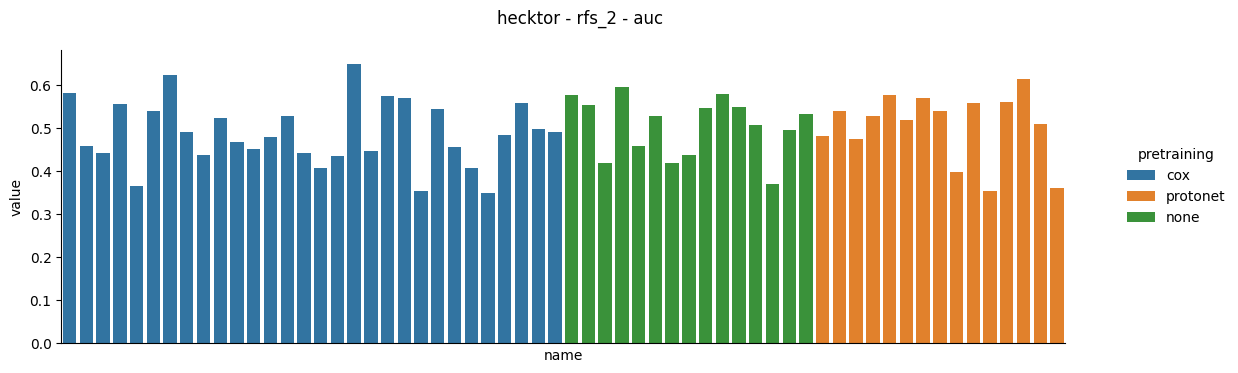

C:\Users\bilel.guetarni\AppData\Local\Temp\3\ipykernel_20792\545065852.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["name"] = subset["pretraining"] + "_" + subset["name"]


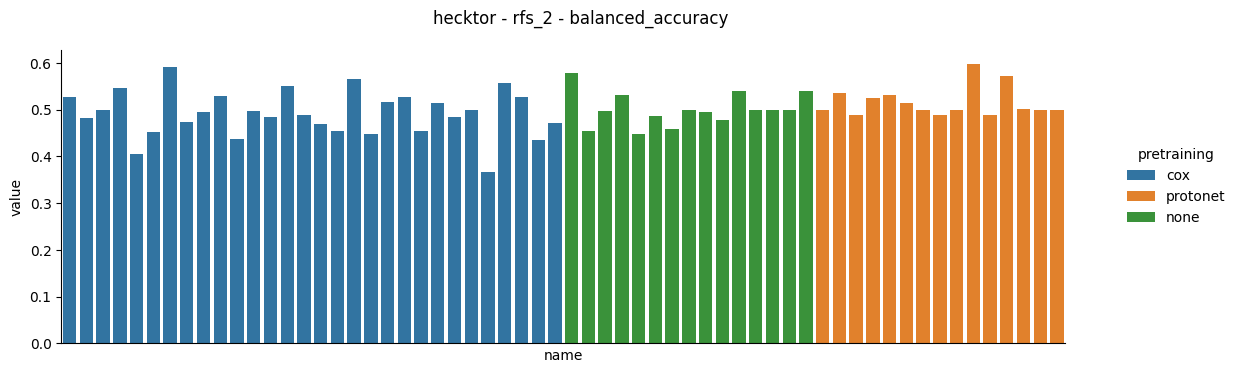

C:\Users\bilel.guetarni\AppData\Local\Temp\3\ipykernel_20792\545065852.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["name"] = subset["pretraining"] + "_" + subset["name"]


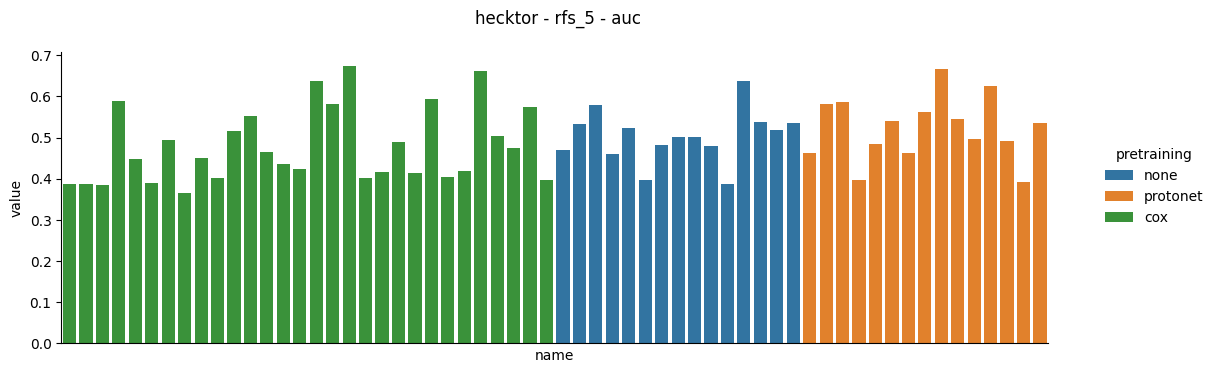

C:\Users\bilel.guetarni\AppData\Local\Temp\3\ipykernel_20792\545065852.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["name"] = subset["pretraining"] + "_" + subset["name"]


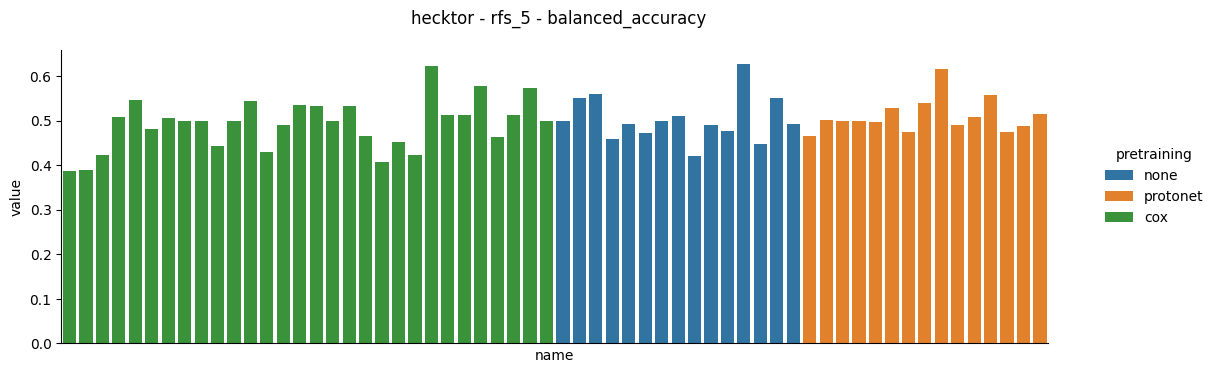

headneckpetct


C:\Users\bilel.guetarni\AppData\Local\Temp\3\ipykernel_20792\545065852.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["name"] = subset["pretraining"] + "_" + subset["name"]


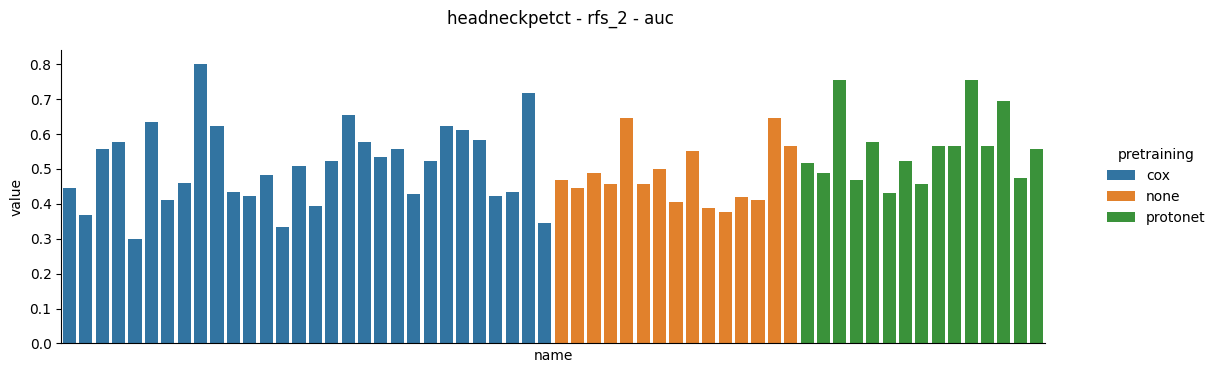

C:\Users\bilel.guetarni\AppData\Local\Temp\3\ipykernel_20792\545065852.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["name"] = subset["pretraining"] + "_" + subset["name"]


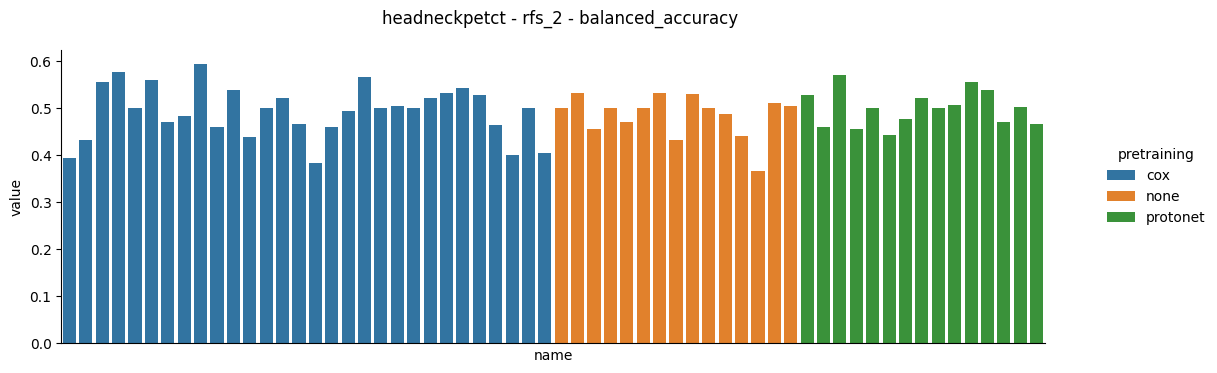

C:\Users\bilel.guetarni\AppData\Local\Temp\3\ipykernel_20792\545065852.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["name"] = subset["pretraining"] + "_" + subset["name"]


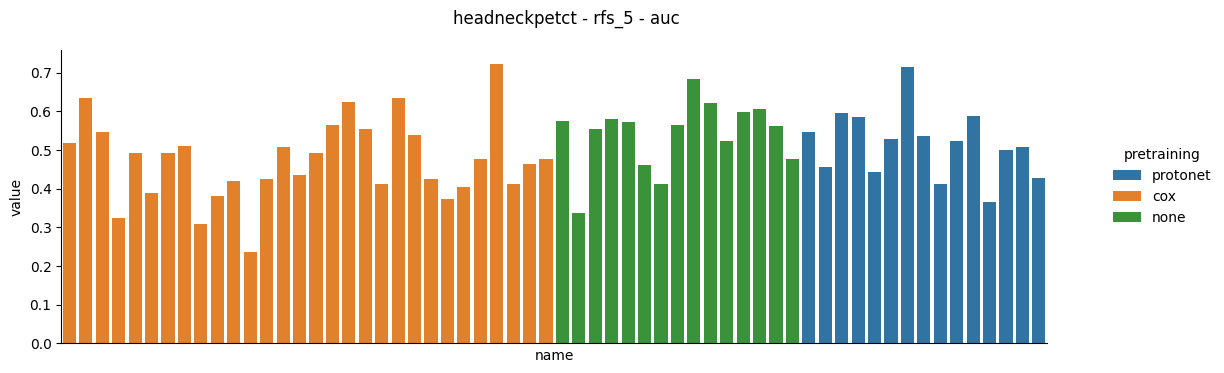

C:\Users\bilel.guetarni\AppData\Local\Temp\3\ipykernel_20792\545065852.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["name"] = subset["pretraining"] + "_" + subset["name"]


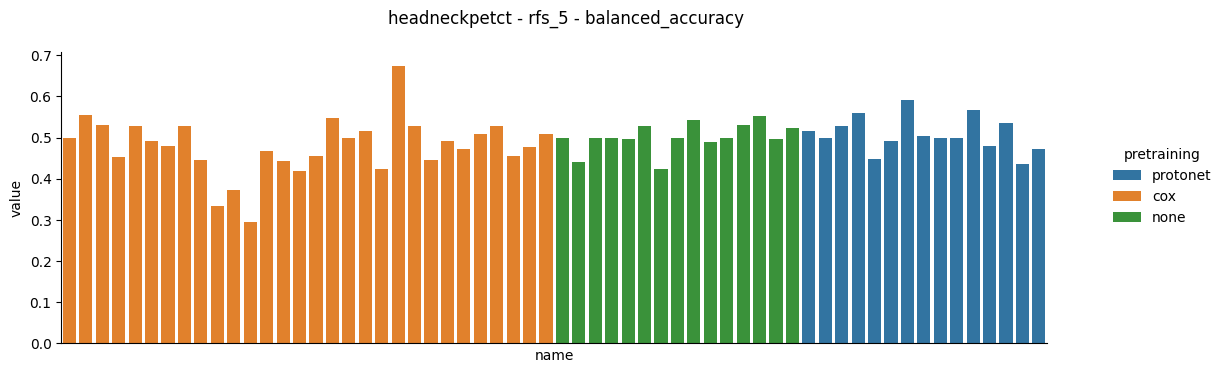

radcure


C:\Users\bilel.guetarni\AppData\Local\Temp\3\ipykernel_20792\545065852.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["name"] = subset["pretraining"] + "_" + subset["name"]


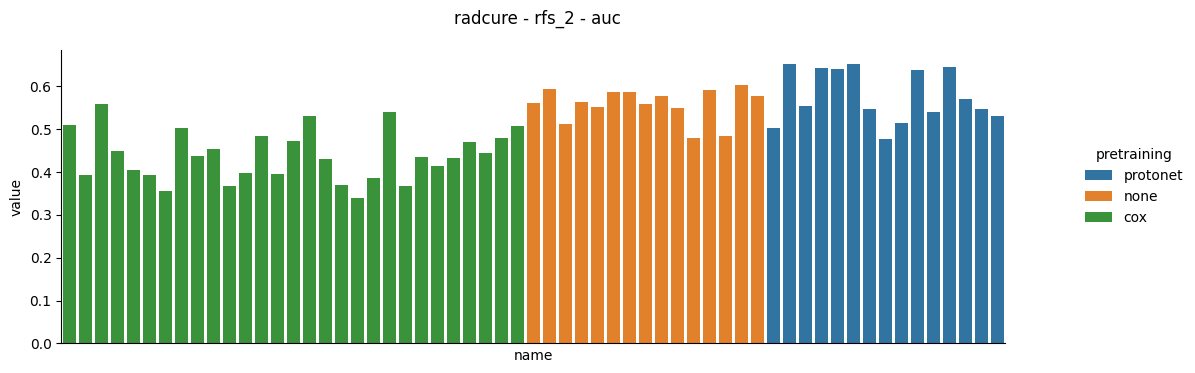

C:\Users\bilel.guetarni\AppData\Local\Temp\3\ipykernel_20792\545065852.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["name"] = subset["pretraining"] + "_" + subset["name"]


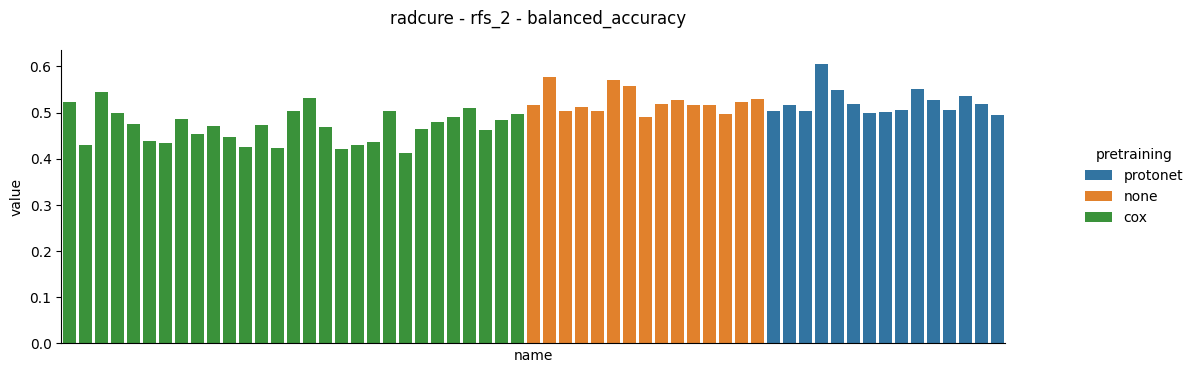

C:\Users\bilel.guetarni\AppData\Local\Temp\3\ipykernel_20792\545065852.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["name"] = subset["pretraining"] + "_" + subset["name"]


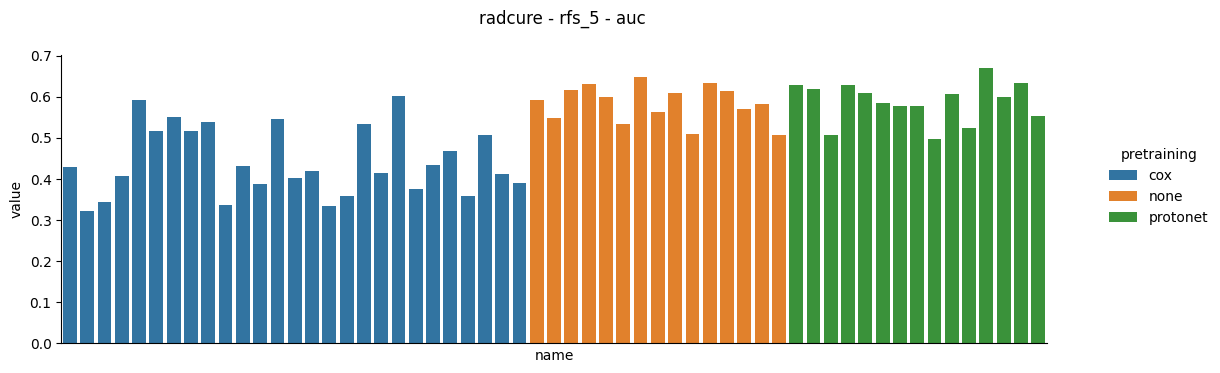

C:\Users\bilel.guetarni\AppData\Local\Temp\3\ipykernel_20792\545065852.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["name"] = subset["pretraining"] + "_" + subset["name"]


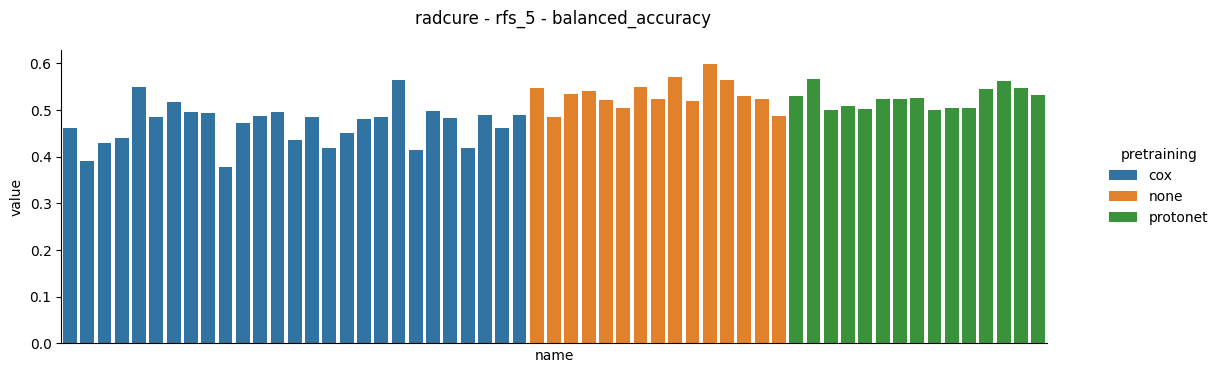

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

dff = df.copy()

for dataset in dff["dataset"].unique():
    print(dataset)

    for task in dff["task"].unique():
            
        for metric in dff['metric'].unique():
            if metric not in ["auc", "balanced_accuracy"]:
                continue

            subset = dff[(dff['metric'] == metric) & (dff['dataset'] == dataset) & (dff["task"] == task)]
            idx = subset[subset["pretraining"].isna()].index
            subset.loc[idx, "pretraining"] = "none"

            subset["name"] = subset["pretraining"] + "_" + subset["name"]
            
            g = sns.catplot(
                data=subset,
                kind="bar",
                x="name",
                y="value",
                hue="pretraining",
                errorbar=None,
                capsize=0.1,
                # legend=False,
                height=4,
                aspect=3,
                order=sorted(subset["name"]),
            )
            
            g.set_titles(row_template="{row_name}", col_template="{col_name}")
            g.set(ylim=(0, 1))
            g.figure.suptitle(f"{dataset} - {task} - {metric}")
            plt.tight_layout()
            plt.xticks(ticks=[], labels=[])
            plt.show()

# 072+ comparison

In [ ]:
import tqdm
import pandas
import pathlib
import json

topk = 10

out_path = r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\combined.csv"
df = []
for path_ in pathlib.Path(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments").glob("*"):
    try:
        if int(path_.name) < 51:
            continue
    except ValueError:
        continue

    print(path_)
    for model_dir in tqdm.tqdm(path_.iterdir()):
        if not(
            (model_dir.joinpath("train_metrics.csv").exists() and model_dir.joinpath("params.json").exists())
            or
            (model_dir.joinpath("metrics.csv").exists() and model_dir.joinpath("params.json").exists())
        ):
            continue
        
        if not(model_dir.joinpath("metrics.csv").exists() and model_dir.joinpath("params.json").exists()):
            continue

        # get best validation loss step
        metrics = pandas.read_csv(model_dir.joinpath("metrics.csv")).drop(columns="Unnamed: 0")   # load model metrics
        
        # get step with lowest validation loss
        valid_metrics = metrics[(metrics["split"] == "valid") & (metrics["metric"] == "log_loss")]   # keep only validation loss
        mean = valid_metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()   # average bootstraps
        min_val_loss_step = mean[["value", "step"]]
        step = min_val_loss_step.loc[min_val_loss_step["value"].idxmin()]["step"]

        # load test metrics        
        # select metrics at step
        test_metrics = metrics[(metrics["split"] == "test") & (metrics["step"] == step)]

        # average over bootstraps
        test_metrics = test_metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()

        # add name and classifier type
        with open(model_dir.joinpath("params.json"), "r") as f:
            p = json.load(f)
            test_metrics["exp"] = path_.name
            test_metrics["dataset"] = p['dataset']
            test_metrics["name"] = model_dir.name
            test_metrics["backbone"] = p['backbone']
            test_metrics["task"] = p["task"]
            test_metrics["modality"] = p["modality"]
            test_metrics["pretraining"] = p["pretraining"]

            if "image" in p["dims"].keys():
                test_metrics["FM-I"] = len(p["dims"]["image"])
            else:
                test_metrics["FM-I"] = None
            
            if "clinical" in p["dims"].keys():
                test_metrics["FM-C"] = p["dims"]["clinical"]
            else:
                test_metrics["FM-C"] = None

        # add to df
        df.extend(test_metrics.to_dict(orient="records"))

df = pandas.DataFrame(df)
df.to_csv(out_path)

for dataset in df["dataset"].unique():
    print(dataset)
    for task in df["task"].unique():
        print(task)
        sub_df = df[(df["dataset"] == dataset) & (df["task"] == task)]
        # get best two lines based on balanced_accuracy
        best_lines = sub_df[sub_df["metric"] == "balanced_accuracy"].sort_values("value", ascending=False).head(topk)["name"].tolist()
        sub_df = sub_df[sub_df["name"].isin(best_lines)]
        # print(sub_df)

        sub_df = sub_df.pivot(index=["dataset", "task", "exp", "pretraining", "modality", "backbone", "name"], columns=["metric"], values="value").sort_values(by="metric", axis=1)

        with pandas.ExcelWriter(rf"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\{dataset}-{task}.xlsx") as writer:
            sub_df.to_excel(writer, sheet_name=f"{dataset}-{task}")

In [ ]:
import tqdm
import pandas
import pathlib
import json

out_path = r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\051-083-sorted.xlsx"
topk = 20

df = []
for path_ in pathlib.Path(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments").glob("*"):
    try:
        if int(path_.name) < 51 or int(path_.name) in (65,66,67):
            continue
    except ValueError:
        continue

    print(path_)
    for model_dir in tqdm.tqdm(path_.iterdir()):
        if not(
            (model_dir.joinpath("train_metrics.csv").exists() and model_dir.joinpath("params.json").exists())
            or
            (model_dir.joinpath("metrics.csv").exists() and model_dir.joinpath("params.json").exists())
        ):
            continue
        
        # get best validation loss step
        if model_dir.joinpath("train_metrics.csv").exists():
            metrics = pandas.read_csv(model_dir.joinpath("train_metrics.csv")).drop(columns="Unnamed: 0")   # load model metrics
        else:
            metrics = pandas.read_csv(model_dir.joinpath("metrics.csv")).drop(columns="Unnamed: 0")   # load model metrics
        
        # get step with lowest validation loss
        valid_metrics = metrics[(metrics["split"] == "valid") & (metrics["metric"] == "log_loss")]   # keep only validation loss
        mean = valid_metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()   # average bootstraps
        min_val_loss_step = mean[["value", "step"]]
        step = min_val_loss_step.loc[min_val_loss_step["value"].idxmin()]["step"]

        # load test metrics        
        # select metrics at step
        if model_dir.joinpath("train_metrics.csv").exists():
            test_metrics = pandas.read_csv(model_dir.joinpath("test_metrics.csv")).drop(columns="Unnamed: 0")
            test_metrics = test_metrics[(test_metrics["split"] == "test") & (test_metrics["step"] == step)]
        else:
            test_metrics = metrics[(metrics["split"] == "test") & (metrics["step"] == step)]

        # average over bootstraps
        test_metrics = test_metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()

        # add name and classifier type
        with open(model_dir.joinpath("params.json"), "r") as f:
            p = json.load(f)
            test_metrics["exp"] = path_.name
            test_metrics["name"] = model_dir.name

            for k in ["dataset", "backbone", "task", "modality", "pretraining"]:
                try:
                    test_metrics[k] = p[k]
                except KeyError:
                    continue

            if (56 < int(path_.name) and int(path_.name) < 62) and bool(p["cox_pretraining"]):
                test_metrics["pretraining"] = p["cox_strategy"]

            if "image" in p["dims"].keys():
                test_metrics["FM-I"] = len(p["dims"]["image"])
            else:
                test_metrics["FM-I"] = None
            
            if "clinical" in p["dims"].keys():
                test_metrics["FM-C"] = p["dims"]["clinical"]
            else:
                test_metrics["FM-C"] = None

        # add to df
        df.extend(test_metrics.to_dict(orient="records"))

df = pandas.DataFrame(df)
idx = df[df["task"] == "R2y"].index
df.loc[idx, "task"] = "rfs_2"
idx = df[df["task"] == "R5y"].index
df.loc[idx, "task"] = "rfs_5"

with pandas.ExcelWriter(out_path) as writer:
    for dataset in df["dataset"].unique():
        print(dataset)
        for task in df["task"].unique():
            print(task)
            sub_df = df[(df["dataset"] == dataset) & (df["task"] == task)]
            
            # get best two lines based on balanced_accuracy
            best_lines = sub_df[sub_df["metric"] == "balanced_accuracy"].sort_values("value", ascending=False).head(topk)["name"].tolist()
            sub_df = sub_df[sub_df["name"].isin(best_lines)]

            sub_df = sub_df.pivot(index=["dataset", "task", "exp", "pretraining", "modality", "backbone", "name"], columns=["metric"], values="value").sort_values(by="metric", axis=1)

            # sort rows by AUC
            sub_df = sub_df.sort_values(by="auc", axis=0, ascending=False)
            
            sub_df.to_excel(writer, sheet_name=f"{dataset}-{task}")

C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\051


16it [00:01, 14.48it/s]


C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\052


16it [00:01, 15.15it/s]


C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\053


...

C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\082


84it [00:03, 27.56it/s]


C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\083


228it [00:07, 28.92it/s]


hecktor
rfs_2
rfs_5
headneckpetct
rfs_2
rfs_5
radcure
rfs_2
rfs_5


hecktor
rfs_2


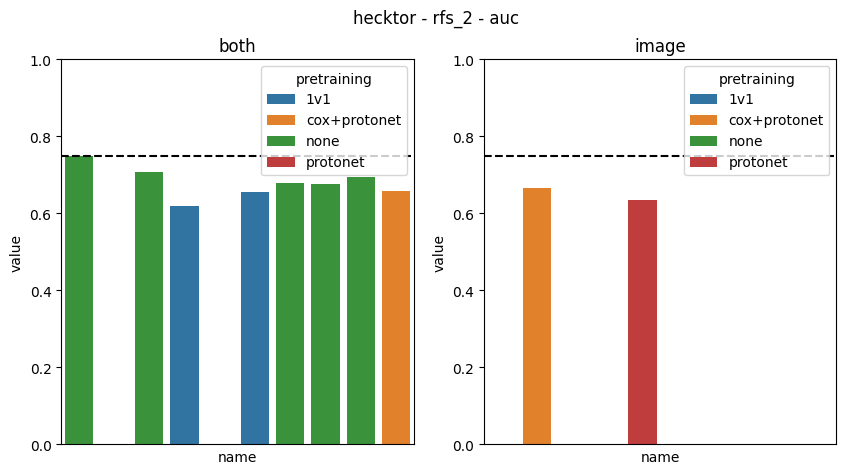

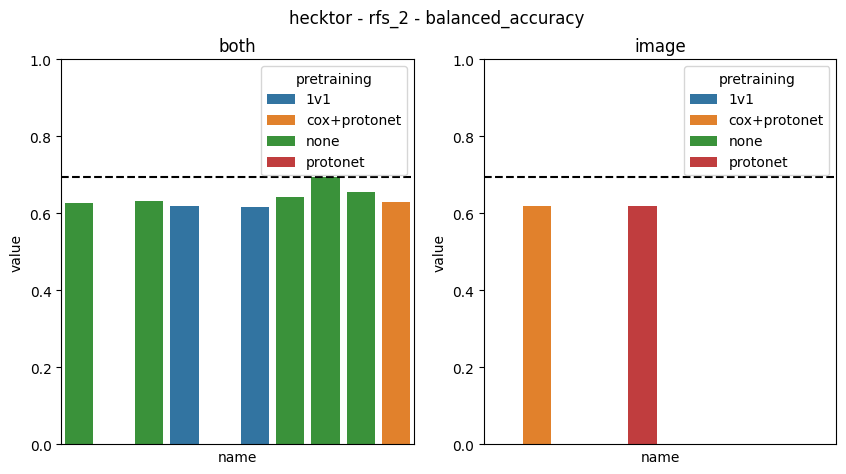

rfs_5


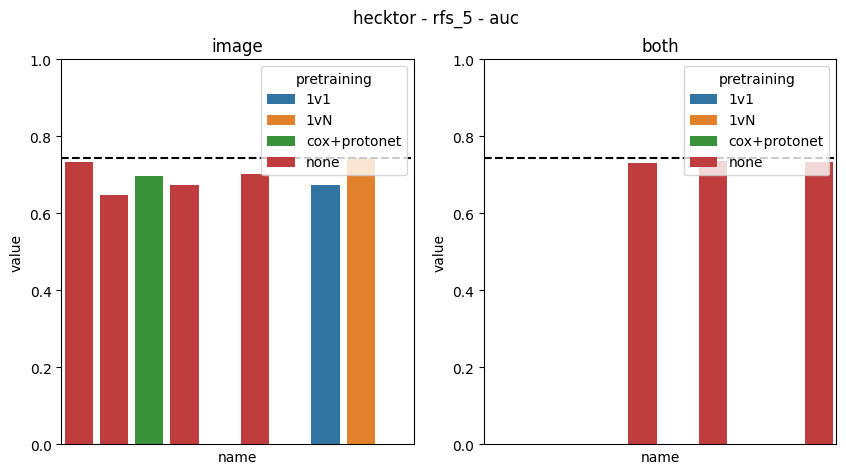

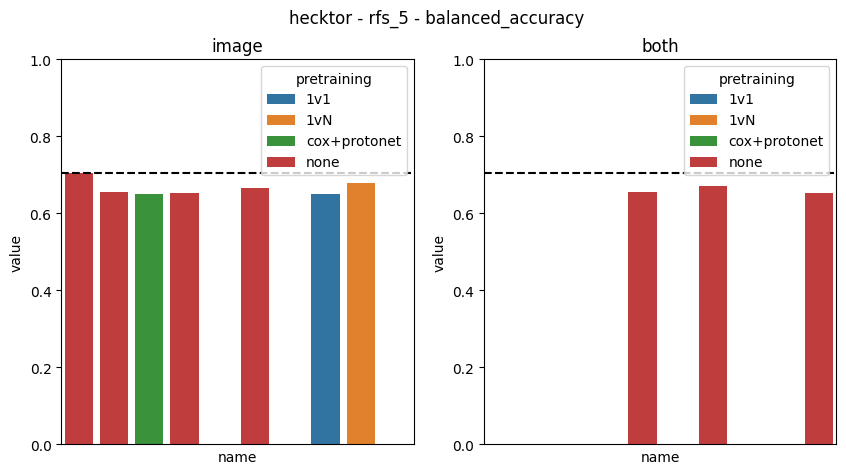

headneckpetct
rfs_2


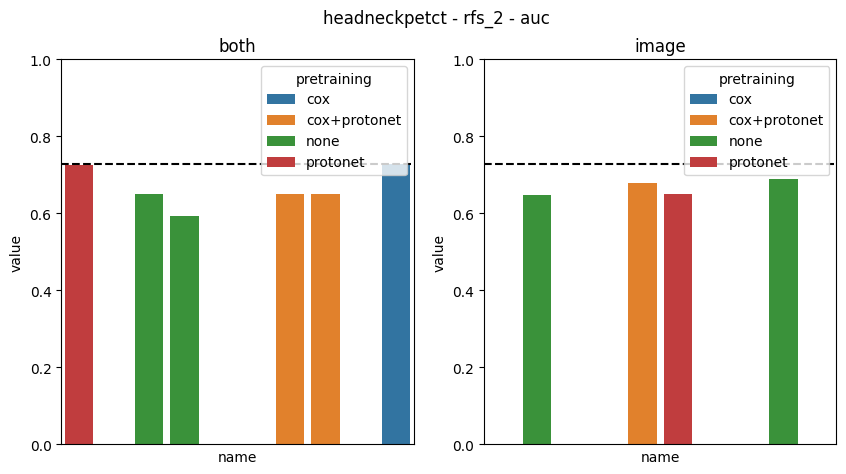

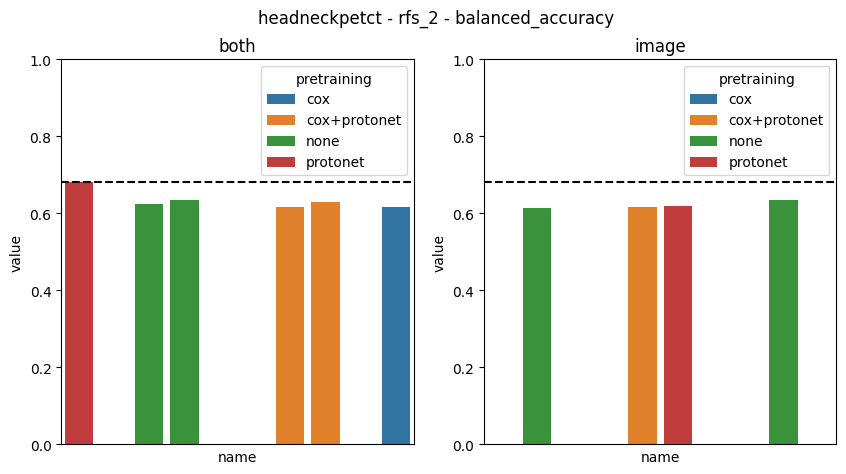

rfs_5


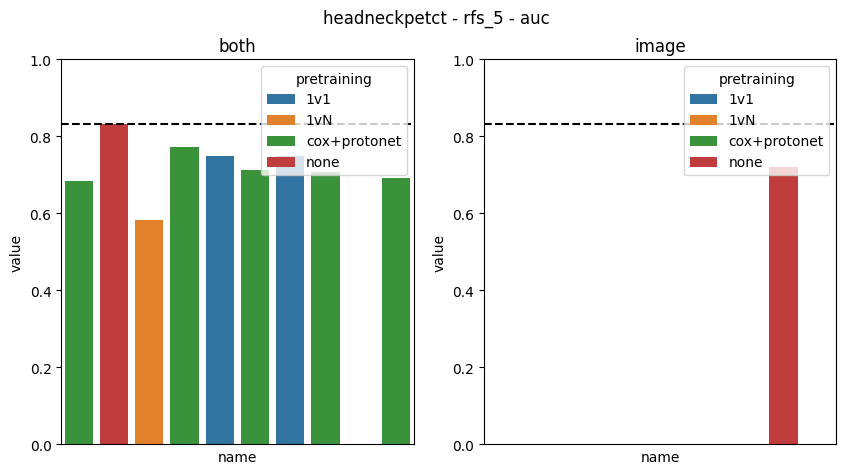

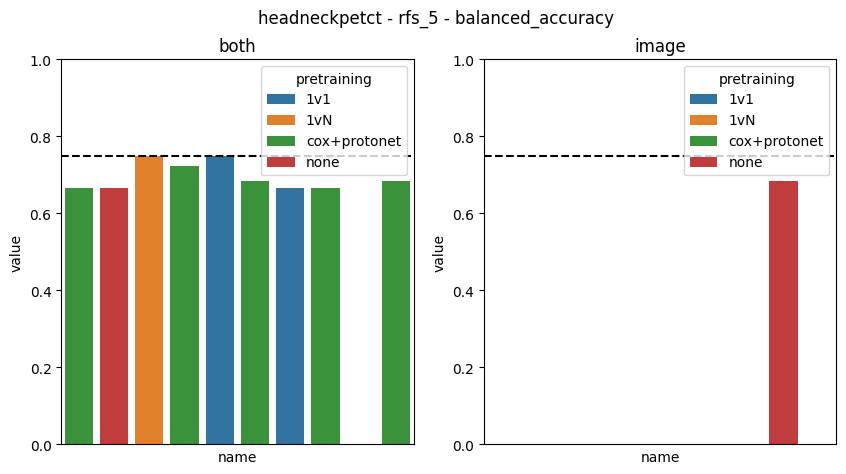

radcure
rfs_2


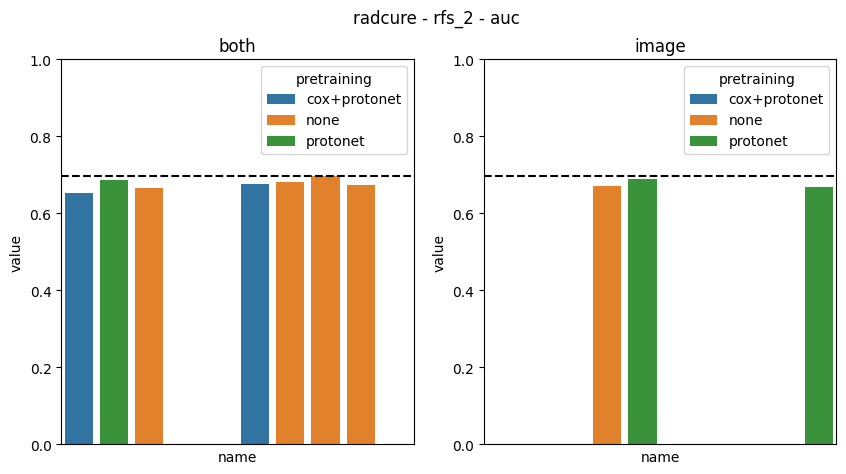

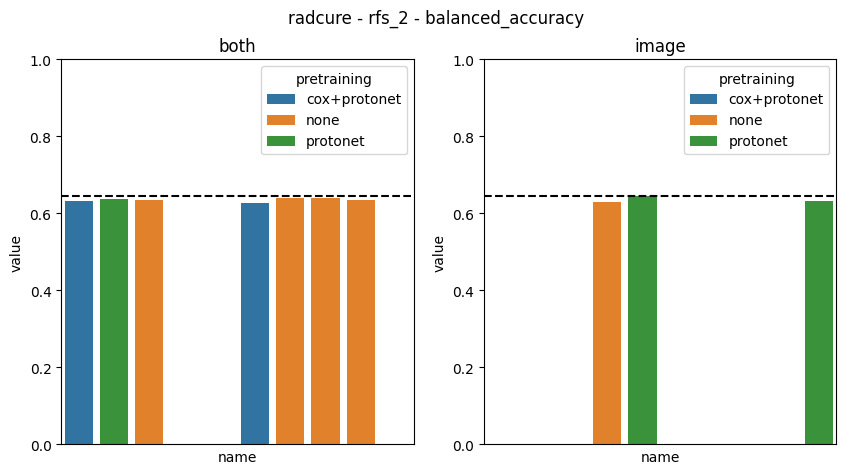

rfs_5


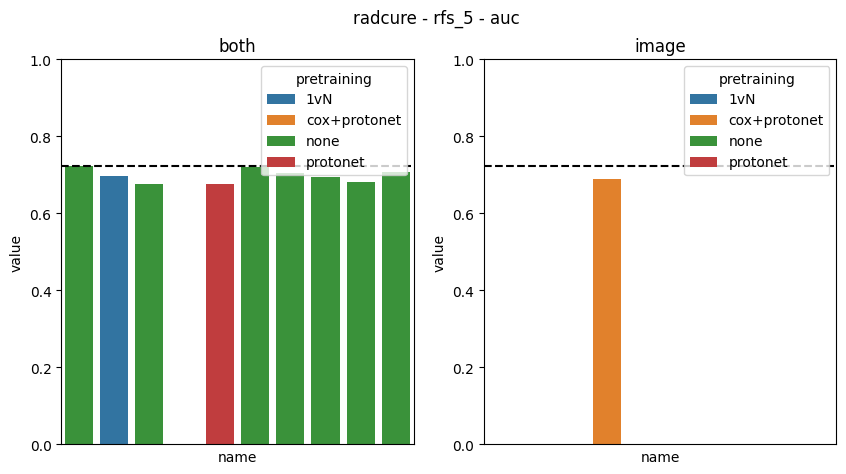

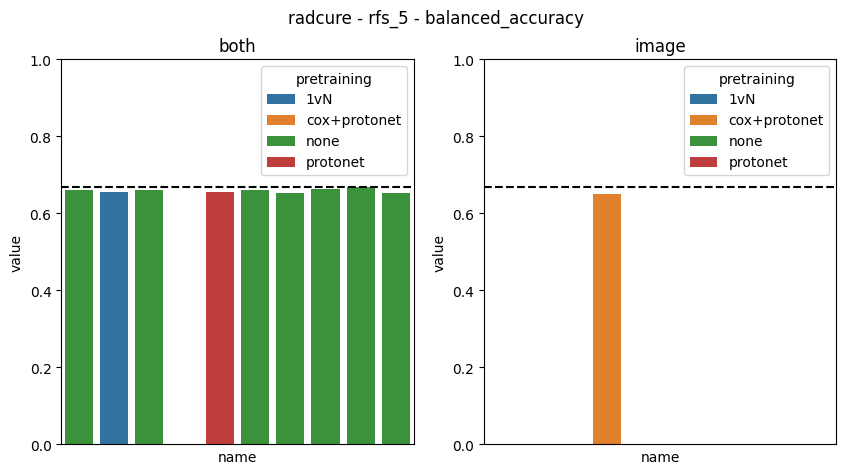

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

topk = 10

for dataset in df["dataset"].unique():
    print(dataset)
    for task in df["task"].unique():
        print(task)
        sub_df = df[(df["dataset"] == dataset) & (df["task"] == task)].copy()
        
        # get best two lines based on balanced_accuracy
        best_lines = sub_df[sub_df["metric"] == "balanced_accuracy"].sort_values("value", ascending=False).head(topk)["name"].tolist()
        sub_df = sub_df[sub_df["name"].isin(best_lines)]

        sub_df.loc[pandas.isna(sub_df["pretraining"]), "pretraining"] = "none"

        for metric in ("auc", "balanced_accuracy"):
            max_ = sub_df[sub_df["metric"] == metric]["value"].max()

            unique_mod = sub_df["modality"].unique()
            f, axes = plt.subplots(1, len(unique_mod), figsize=(10, 5), sharex=False)
            for m, ax in zip(unique_mod, axes):
                g = sns.barplot(
                    data=sub_df[(sub_df["metric"] == metric) & (sub_df["modality"] == m)],
                    x="name",
                    y="value",
                    hue="pretraining",
                    hue_order=sorted(sub_df["pretraining"].unique()),
                    errorbar=None,
                    capsize=0.1,
                    legend=True,
                    order=sorted(sub_df["name"]),
                    ax=ax,
                )
                ax.set(ylim=(0, 1))
                ax.set_xticks(ticks=[], labels=[])
                ax.axhline(max_, color="black", linestyle="--")
                ax.set_title(m)
                sns.move_legend(ax, "upper right")
            f.suptitle(f"{dataset} - {task} - {metric}")
            plt.show()

## ROC curves

In [ ]:
import os
import json
from sklearn.metrics import roc_curve
import glob

data = []
for model_path in glob.glob(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\083\*"):
    name = os.path.split(model_path)[1]
    exp = os.path.split(os.path.split(model_path)[0])[1]
    with open(os.path.join(model_path, "params.json"), "r") as f:
        p = json.load(f)

    metrics = pandas.read_csv(os.path.join(model_path, "metrics.csv")).drop(columns="Unnamed: 0")
    
    valid_metrics = metrics[(metrics["split"] == "valid") & (metrics["metric"] == "log_loss")]
    mean = valid_metrics.groupby(["split", "metric", "run", "step"])["value"].mean().reset_index()
    steps = {run: mean[mean["run"] == run].sort_values(by="value", axis=0, ascending=True, ignore_index=True).loc[0]["step"] for run in mean["run"].unique()}

    with open(os.path.join(model_path, "test_pred_proba.json"), "r") as f:
        ytrue_pred = json.load(f)

    for fold, values in ytrue_pred.items():
        # list of steps as integers
        step_list = [int(i["step"]) for i in values]
        # select values at step corresponding to fold
        values = values[step_list.index(steps[int(fold)])]

        # get y_true and y_pred_proba
        y_true = values["y_true"]
        y_pred_proba = values["y_pred_proba"]

        # compute fpr and tpr and add to data
        for fpr, tpr, _ in zip(*roc_curve(y_true, y_pred_proba)):
            data.append({"fpr": fpr, "tpr": tpr, "fold": fold,
                       "dataset": p["dataset"], "exp": exp, "task": p["task"], "name": name, "modality": p["modality"]})

In [ ]:
import matplotlib.pyplot as plt
import random

df = pandas.DataFrame(data)
for dataset in df["dataset"].unique():
    print(dataset)
    dataset_df = df[df["dataset"] == dataset]
    names = random.sample(dataset_df["name"].unique().tolist(), 1)
    print(names[0])
    dataset_df = dataset_df[dataset_df["name"].isin(names)]
    sns.lineplot(data=dataset_df, x="fpr", y="tpr", hue="fold", estimator=None)
    plt.plot([0, 1], [0, 1], color="black", linestyle="--")
    plt.show()

average over folds by interpolating the different ROC curves

radcure
rfs_2


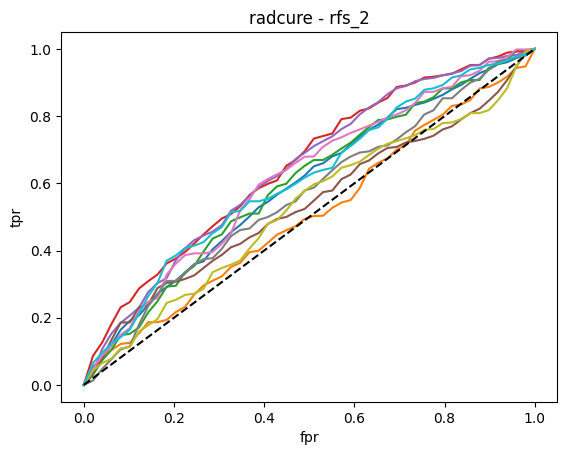

rfs_5


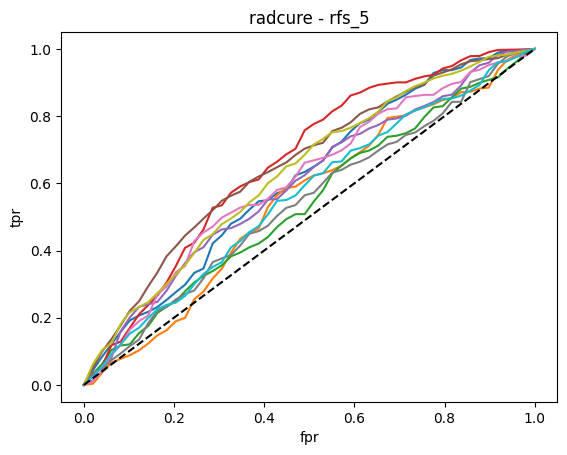

hecktor
rfs_2


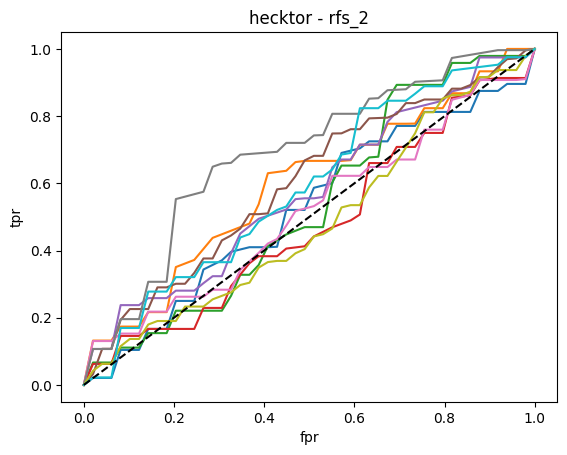

rfs_5


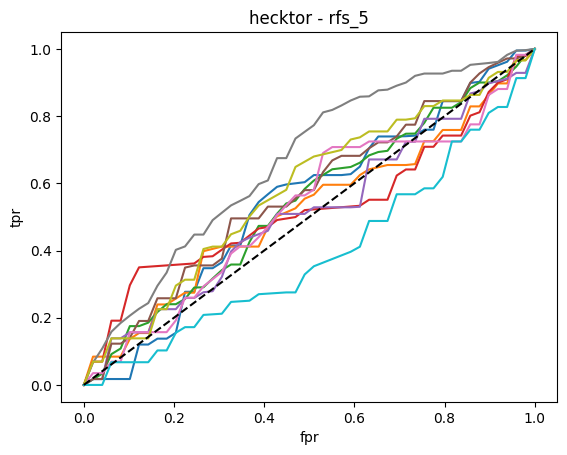

headneckpetct
rfs_2


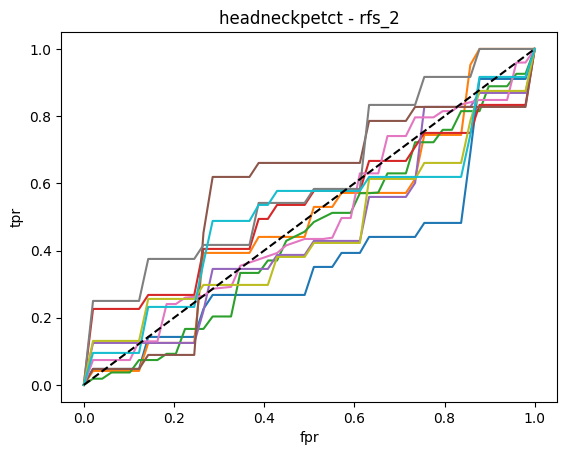

rfs_5


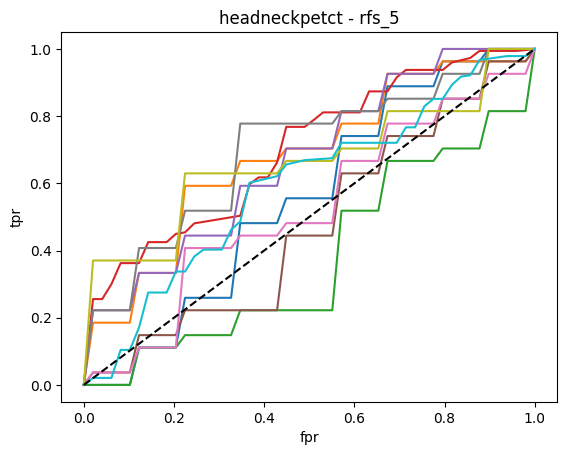

In [111]:
import matplotlib.pyplot as plt
import random

import numpy as np
import pandas as pd

import numpy as np

def get_average_roc(df, n_points=100):
    """
    Computes a single average ROC curve from multiple folds.
    
    Args:
        df: A DataFrame containing 'fpr', 'tpr', and 'fold' columns for each fold's ROC curve
        n_points: Number of points in the resulting lists
        
    Returns:
        mean_fpr: A single list of FPR values
        mean_tpr: A single list of averaged TPR values
    """
    
    fpr_list = [df[df["fold"] == fold]["fpr"].tolist() for fold in sorted(df["fold"].unique())]
    tpr_list = [df[df["fold"] == fold]["tpr"].tolist() for fold in sorted(df["fold"].unique())]
    
    # 1. Create the common X-axis (FPR)
    mean_fpr = np.linspace(0, 1, n_points)
    interp_tprs = []

    # 2. Interpolate each fold
    for fpr, tpr in zip(fpr_list, tpr_list):
        indices = np.argsort(fpr)
        # Linear interpolation
        interp_tpr = np.interp(mean_fpr, np.array(fpr)[indices], np.array(tpr)[indices])
        # Ensure fold itself is monotonic
        interp_tpr = np.maximum.accumulate(interp_tpr)
        interp_tprs.append(interp_tpr)

    # 3. Average the TPRs across all folds
    mean_tpr = np.mean(interp_tprs, axis=0)
    
    # 4. Final safety checks for a valid ROC curve
    mean_tpr = np.maximum.accumulate(mean_tpr) # Ensure strictly increasing
    mean_tpr[0] = 0.0
    mean_tpr[-1] = 1.0

    return mean_fpr.tolist(), mean_tpr.tolist()

df = pandas.DataFrame(data)
for dataset in df["dataset"].unique():
    print(dataset)
    for task in df["task"].unique():
        print(task)

        df_dataset = df[(df["dataset"] == dataset) & (df["task"] == task)]
        dataset_data = []
        for name in random.sample(df_dataset["name"].unique().tolist(), 10):
            df_dataset_name = df_dataset[df_dataset["name"] == name]
            fpr, tpr = get_average_roc(df_dataset_name, n_points=50)
            dataset_data.extend([{"fpr": f, "tpr": t, "name": name} for f, t in zip(fpr, tpr)])

        sns.lineplot(data=pandas.DataFrame(dataset_data), x="fpr", y="tpr", hue="name", estimator=None, legend=False)
        plt.plot([0, 1], [0, 1], color="black", linestyle="--")
        plt.title(f"{dataset} - {task}")
        plt.savefig(rf"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\roc-{dataset}-{task}.png")
        plt.show()

## 051-083 balanced accuracy and ROC curves

In [2]:
import json
import pandas
import tqdm
from sklearn.metrics import roc_curve
import pathlib

data = []
data_metrics = []
for exp_path in pathlib.Path(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments").glob("*"):
    try:
        if int(exp_path.name) < 51 or int(exp_path.name) in (65,66,67):
            continue
    except ValueError:
        continue

    print(exp_path)
    for model_dir in tqdm.tqdm(exp_path.iterdir()):

        if not (model_dir.joinpath("test_pred_proba.json").exists()):
            continue

        with open(model_dir.joinpath("params.json"), "r") as f:
            p = json.load(f)

        if model_dir.joinpath("train_metrics.csv").exists():
            metrics = pandas.read_csv(model_dir.joinpath("train_metrics.csv")).drop(columns="Unnamed: 0")
        else:
            metrics = pandas.read_csv(model_dir.joinpath("metrics.csv")).drop(columns="Unnamed: 0")

        valid_metrics = metrics[(metrics["split"] == "valid") & (metrics["metric"] == "log_loss")]   # keep only validation loss
        mean = valid_metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()   # average bootstraps
        min_val_loss_step = mean[["value", "step"]]
        step = min_val_loss_step.loc[min_val_loss_step["value"].idxmin()]["step"]
        

        test_metrics = metrics[(metrics["split"] == "test") & (metrics["step"] == step)& (metrics["metric"].isin(["auc", "balanced_accuracy"]))]
        test_metrics = test_metrics.groupby(["split", "metric", "step"])["value"].mean().reset_index()
        test_metrics["exp"] = exp_path.name
        test_metrics["name"] = model_dir.name
        test_metrics["task"] = p["task"]
        test_metrics["dataset"] = p["dataset"]
        test_metrics["modality"] = p["modality"]
        data_metrics.extend(test_metrics.to_dict(orient="records"))

        with open(model_dir.joinpath("test_pred_proba.json"), "r") as f:
            ytrue_pred = json.load(f)

        for fold, values in ytrue_pred.items():
            # list of steps as integers
            step_list = [int(i["step"]) for i in values]
            # select values at step corresponding to fold
            values = values[step_list.index(step)]

            # get y_true and y_pred_proba
            y_true = values["y_true"]
            y_pred_proba = values["y_pred_proba"]

            # compute fpr and tpr and add to data
            for fpr, tpr, _ in zip(*roc_curve(y_true, y_pred_proba)):
                data.append({"fpr": fpr, "tpr": tpr, "fold": fold,
                        "dataset": p["dataset"], "exp": exp_path.name, "task": p["task"], "name": model_dir.name, "modality": p["modality"]})

C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\051


16it [00:00, ?it/s]


C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\052


16it [00:00, 1604.02it/s]


C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\053


...

84it [00:05, 16.04it/s]


C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\083


228it [00:15, 15.10it/s]


C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\experiments\084


20it [00:03,  5.52it/s]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def get_average_roc(df, n_points=100):
    """
    Computes a single average ROC curve from multiple folds.
    
    Args:
        df: A DataFrame containing 'fpr', 'tpr', and 'fold' columns for each fold's ROC curve
        n_points: Number of points in the resulting lists
        
    Returns:
        mean_fpr: A single list of FPR values
        mean_tpr: A single list of averaged TPR values
    """
    
    fpr_list = [df[df["fold"] == fold]["fpr"].tolist() for fold in sorted(df["fold"].unique())]
    tpr_list = [df[df["fold"] == fold]["tpr"].tolist() for fold in sorted(df["fold"].unique())]
    
    # 1. Create the common X-axis (FPR)
    mean_fpr = np.linspace(0, 1, n_points)
    interp_tprs = []

    # 2. Interpolate each fold
    for fpr, tpr in zip(fpr_list, tpr_list):
        indices = np.argsort(fpr)
        # Linear interpolation
        interp_tpr = np.interp(mean_fpr, np.array(fpr)[indices], np.array(tpr)[indices])
        # Ensure fold itself is monotonic
        interp_tpr = np.maximum.accumulate(interp_tpr)
        interp_tprs.append(interp_tpr)

    # 3. Average the TPRs across all folds
    mean_tpr = np.mean(interp_tprs, axis=0)
    
    # 4. Final safety checks for a valid ROC curve
    mean_tpr = np.maximum.accumulate(mean_tpr) # Ensure strictly increasing
    mean_tpr[0] = 0.0
    mean_tpr[-1] = 1.0

    return mean_fpr.tolist(), mean_tpr.tolist()

df = pandas.DataFrame(data)
test_metrics = pandas.DataFrame(data_metrics)

for dataset in df["dataset"].unique():
    print(dataset)
    for task in df["task"].unique():
        print(task)

        df_dataset = df[(df["dataset"] == dataset) & (df["task"] == task)]
        test_metrics_dataset = test_metrics[(test_metrics["dataset"] == dataset) & (test_metrics["task"] == task)].copy()

        best_names = test_metrics_dataset[test_metrics_dataset["metric"] == "balanced_accuracy"].sort_values("value", ascending=False).head(10)["name"].tolist()
        
        test_metrics_dataset = test_metrics_dataset[test_metrics_dataset["name"].isin(best_names)]        
        test_metrics_dataset = test_metrics_dataset.pivot(index=["dataset", "task", "exp", "name"], columns=["metric"], values="value").reset_index()
        test_metrics_dataset.to_excel(rf"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\roc\roc-{dataset}-{task}.xlsx")
        
        # for name in best_names:
        #     print(name)
        #     auc = test_metrics_dataset[(test_metrics_dataset["name"] == name) & (test_metrics_dataset["metric"] == "auc")]["value"].values[0]
        #     ba = test_metrics_dataset[(test_metrics_dataset["name"] == name) & (test_metrics_dataset["metric"] == "balanced_accuracy")]["value"].values[0]
        #     print(f"\t auc {auc:.3f}")
        #     print(f"\t balanced acc {ba:.3f}")

        dataset_data = []
        for name in best_names:
            df_dataset_name = df_dataset[df_dataset["name"] == name]
            fpr, tpr = get_average_roc(df_dataset_name, n_points=50)
            dataset_data.extend([{"fpr": f, "tpr": t, "name": name[:7]} for f, t in zip(fpr, tpr)])

        sns.lineplot(data=pandas.DataFrame(dataset_data), x="fpr", y="tpr", hue="name", estimator=None, legend=True)
        plt.plot([0, 1], [0, 1], color="black", linestyle="--")
        plt.title(f"{dataset} - {task}")
        plt.savefig(rf"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\roc\roc-{dataset}-{task}.png")
        plt.show()